# Set-Up

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
 import numpy as np

In [3]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Intro

* So far, only **high-level API (Keras)** has been used for building models

* Using Keras, we have already built:

  * Regression models
  * Classification models
  * Wide & Deep networks
  * Self-normalizing neural networks

* Applied key techniques:

  * Batch normalization
  * Dropout
  * Learning rate scheduling

* Around **95% of real-world ML use cases** can be solved using:

  * Keras
  * tf.data (for data pipelines)

* Need for **low-level TensorFlow API (TensorFlow)** arises when:

  * More control over model behavior is required

* Low-level API allows customization of:

  * Loss functions
  * Metrics
  * Layers
  * Models
  * Initializers
  * Regularizers
  * Weight constraints

* Enables **full control over training loop**, including:

  * Custom gradient transformations
  * Applying constraints beyond gradient clipping
  * Using multiple optimizers for different parts of a model

* Introduction to **automatic graph generation (computational graph optimization)**:

  * Helps improve performance of custom models and training processes

* This chapter focuses on:

  * Exploring TensorFlow’s lower-level API
  * Understanding advanced customization and control
  * Learning performance optimization via graph execution


# A Quick Tour of TensorFlow

* TensorFlow is a **powerful numerical computation library**, especially optimized for **large-scale machine learning**

* Developed by **Google Brain team** and used in major systems like:

  * Google Cloud Speech
  * Google Photos
  * Google Search

* Open sourced in **November 2015**

* One of the **most widely used deep learning libraries** in industry

* Common use cases:

  * Image classification
  * Natural language processing (NLP)
  * Recommender systems
  * Time series forecasting

---

* Core characteristics:

  * Similar to **NumPy-style computation**
  * Adds **GPU support** for faster processing

* Supports **distributed computing**:

  * Across multiple devices (CPU, GPU, TPU)
  * Across multiple servers

* Includes **Just-In-Time (JIT) compilation**:

  * Converts Python functions → **computation graph**
  * Optimizations include:

    * Removing unused nodes (pruning)
    * Parallel execution of independent operations
  * Improves:

    * Speed
    * Memory efficiency

---

* **Computation graph portability**:

  * Models can be trained in one environment and deployed in another
  * Example:

    * Train: Python (Linux)
    * Deploy: Java (Android)

---

* Supports **reverse-mode automatic differentiation (autodiff)**:

  * Efficient gradient computation for training

* Built-in optimizers include:

  * RMSProp
  * Nadam

---

* High-level ecosystem features:

  * Keras (main high-level API)
  * Data pipelines:

    * tf.data
    * tf.io
  * Image processing:

    * tf.image
  * Signal processing:

    * tf.signal

---

* Low-level implementation:

  * Each operation (**op**) is written in **highly efficient C++**

* Uses **kernels**:

  * Multiple implementations of same operation
  * Optimized for specific hardware:

    * CPU
    * GPU
    * TPU

---

* Hardware acceleration:

  * **GPU**:

    * Parallel execution using many threads
    * Speeds up large computations

  * **TPU (Tensor Processing Unit)**:

    * Custom-built ASIC chips for deep learning
    * Even faster than GPUs for specific ML workloads


| Module / API            | Category             | Purpose                                | Key Functions / Features                      | When You Use It                 |
| ----------------------- | -------------------- | -------------------------------------- | --------------------------------------------- | ------------------------------- |
| tf.keras                | High-level API       | Build and train neural networks easily | Sequential, Functional API, Model subclassing | Default choice for 95% ML tasks |
| tf.nn                   | Low-level DL API     | Fine-grained neural network ops        | activations, convolutions, loss ops           | Custom layer/model building     |
| tf.GradientTape         | Autodiff             | Automatic differentiation              | gradient computation, backprop control        | Custom training loops           |
| tf.math                 | Math ops             | Core mathematical operations           | add, multiply, reduce, etc.                   | Basic tensor computations       |
| tf.linalg               | Linear algebra       | Matrix operations                      | matmul, inverse, eig                          | ML math-heavy ops               |
| tf.signal               | Signal processing    | FFT, filtering                         | spectrograms, transforms                      | Audio/time-series               |
| tf.random               | Random ops           | Random number generation               | normal, uniform                               | Initialization, sampling        |
| tf.bitwise              | Bit ops              | Bit-level operations                   | AND, OR, XOR                                  | Low-level optimizations         |
| tf.data                 | Data pipeline        | Efficient data loading                 | Dataset API, batching, prefetch               | Large-scale data handling       |
| tf.io                   | Input/output         | File handling                          | read/write files                              | Data ingestion                  |
| tf.image                | Image processing     | Image transformations                  | resize, augment                               | CV tasks                        |
| tf.audio                | Audio processing     | Audio data ops                         | decode, encode                                | Audio ML                        |
| tf.queue                | Data queueing        | Input pipelines (legacy)               | queues                                        | Old pipelines (rare now)        |
| tf.summary              | Visualization        | Logging for TensorBoard                | scalars, histograms                           | Training monitoring             |
| tf.distribute           | Distributed training | Multi-device training                  | MirroredStrategy, etc.                        | Scale training                  |
| tf.saved_model          | Model saving         | Export models                          | save/load portable models                     | Deployment                      |
| tf.function (autograph) | Graph conversion     | Convert Python → graph                 | JIT compilation                               | Performance optimization        |
| tf.graph_util           | Graph tools          | Graph manipulation                     | pruning, transforms                           | Optimization/debugging          |
| tf.lite                 | Mobile deployment    | Lightweight models                     | convert to TFLite                             | Mobile/edge devices             |
| tf.quantization         | Optimization         | Model compression                      | quantize weights                              | Faster inference                |
| tf.tpu                  | TPU support          | TPU execution                          | TPU strategy                                  | High-speed training             |
| tf.xla                  | Compiler             | Accelerated execution                  | JIT compile kernels                           | Performance boost               |
| tf.lookup               | Data structures      | Lookup tables                          | hash tables                                   | NLP, mappings                   |
| tf.nest                 | Structure utils      | Nested structure handling              | flatten, map                                  | Complex data pipelines          |
| tf.ragged               | Special tensors      | Variable-length tensors                | ragged tensors                                | NLP sequences                   |
| tf.sparse               | Sparse tensors       | Memory-efficient tensors               | sparse ops                                    | Large sparse data               |
| tf.sets                 | Set ops              | Set operations                         | union, intersection                           | Data preprocessing              |
| tf.strings              | String ops           | Text processing                        | split, join                                   | NLP preprocessing               |
| tf.experimental         | Experimental         | New features                           | unstable APIs                                 | Testing new features            |
| tf.config               | System config        | Hardware setup                         | GPU/CPU config                                | Resource control                |


* In most cases, TensorFlow workflow uses:

  * High-level APIs:

    * Keras
    * tf.data
  * For flexibility → use **low-level Python API** (direct tensor manipulation)

* TensorFlow execution engine:

  * Automatically runs operations efficiently
  * Handles:

    * Multi-device execution (CPU, GPU, TPU)
    * Distributed systems (multiple machines)

---

* Cross-platform support:

  * Runs on:

    * Windows
    * Linux
    * macOS

* Mobile deployment:

  * TensorFlow Lite supports:

    * Android
    * iOS

---

* Multi-language support:

  * Python (main)
  * C++
  * Java
  * Swift
  * TensorFlow.js:

    * Run ML models directly in browser

---

* TensorFlow ecosystem (beyond core library):

  * TensorBoard:

    * Visualization of training metrics
    * Graphs, losses, histograms

  * TensorFlow Extended (TFX):

    * Production pipeline tools:

      * Data validation
      * Data preprocessing
      * Model analysis
      * Model serving

  * TensorFlow Serving:

    * Deploy models in production environments

  * TensorFlow Hub:

    * Download and reuse pretrained models

  * TensorFlow Model Garden:

    * Collection of architectures (some pretrained)

---

* Availability of resources:

  * Many open-source TensorFlow projects on GitHub
  * Easy to find reusable implementations

* Research + implementation ecosystem:

  * Papers with Code:

    * Provides papers with implementations
    * Sometimes includes pretrained models

---

* Community support:

  * Active developer community
  * Platforms:

    * StackOverflow (for technical questions)
    * GitHub (bugs & feature requests)
    * TensorFlow Forum (discussions)

---

* Key takeaway:

  * TensorFlow is not just a library
  * It is a **complete ecosystem for ML development → deployment → scaling**


# Using TensorFlow like NumPy

* TensorFlow API is centered around **tensors**

* **Tensors flow between operations**:

  * Output of one operation → input to another
  * This data flow gives the name **TensorFlow**

---

* A **tensor** is:

  * Very similar to a NumPy ndarray
  * A **multidimensional array**

* A tensor can also represent:

  * A **scalar (0D tensor)** → single value

    * Example: 42

---

* Types of tensors based on dimensions:

  * 0D → Scalar
  * 1D → Vector
  * 2D → Matrix
  * nD → Higher-dimensional tensor

---

* Tensors are the **core data structure** in TensorFlow:

  * All computations happen using tensors
  * All operations take tensors as input and produce tensors as output

---

* Importance of tensors in advanced usage:

  * Required for building:

    * Custom loss functions
    * Custom metrics
    * Custom layers
    * Custom models

---

* Key takeaway:

  * Understanding tensors = **foundation for mastering low-level TensorFlow**


## Tensors and Operations

You can create a tensor with tf.constant()

In [3]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])

In [4]:
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [5]:
t.shape

TensorShape([2, 3])

In [6]:
t.dtype

tf.float32

In [7]:
t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [8]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

In [9]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [10]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [11]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

In [12]:
 tf.constant(42) #scaler value

<tf.Tensor: shape=(), dtype=int32, numpy=42>

* Writing operations using Python operators:

  * `t + 10` → internally calls `tf.add(t, 10)`
  * Uses Python magic method:

    * ( t.**add**(10) \rightarrow tf.add(t, 10) )

* Other supported operators:

  * `-` → subtraction
  * `*` → multiplication
  * `@` → matrix multiplication

    * Equivalent to:

      * ( t_1 @ t_2 = tf.matmul(t_1, t_2) )

---

* Function aliases in TensorFlow:

  * ( tf.add() = tf.math.add() )
  * Purpose:

    * Short names for common ops
    * Organized module structure

---

* Scalar tensors:

  * Tensor can store a single value
  * Shape is empty:

    * ( shape = () )

---

* Keras backend (tf.keras.backend):

  * Previously used for:

    * ( K.square(), K.exp(), K.sqrt() )
  * Now:

    * Prefer TensorFlow direct functions:

      * ( tf.square(), tf.exp(), tf.sqrt() )
  * Still exists for backward compatibility
  * Useful utility:

    * clear_session()

---

* Common TensorFlow math operations:

  * ( tf.add() )
  * ( tf.multiply() )
  * ( tf.square() )
  * ( tf.exp() )
  * ( tf.sqrt() )

* NumPy-equivalent operations:

  * ( tf.reshape() )
  * ( tf.squeeze() )
  * ( tf.tile() )

---

* Differences in naming vs NumPy:

  * ( tf.reduce_mean() \approx np.mean() )
  * ( tf.reduce_sum() \approx np.sum() )
  * ( tf.reduce_max() \approx np.max() )
  * ( tf.math.log() \approx np.log() )

---

* Important design differences from NumPy:

  * Transpose:

    * TensorFlow:

      * ( tf.transpose(t) ) → creates **new tensor (copy)**
    * NumPy:

      * ( t.T ) → creates **view (no copy)**

  * Reduction operations:

    * ( tf.reduce_sum(), tf.reduce_mean() ):

      * Use **parallel reduction algorithms (GPU)**
      * Order of operations not fixed
      * Result may vary slightly due to floating-point precision

    * ( tf.reduce_max() ):

      * Deterministic (no precision issue from ordering)

---

* Key takeaway:

  * TensorFlow ops are:

    * More explicit than NumPy
    * Designed for **parallel computation + hardware efficiency**
    * May sacrifice strict determinism for performance in some cases


## Tensors and NumPy

>Notice that NumPy uses 64-bit precision by default, while TensorFlow uses 32-bit. This is
because 32-bit precision is generally more than enough for neural networks, plus it runs
faster and uses less RAM. So when you create a tensor from a NumPy array, make sure to
set dtype=tf.float32

In [14]:
import numpy as np

a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [15]:
t.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [16]:
np.array(t)

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [17]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [18]:
np.square(t)

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

## Type Conversions

1. TensorFlow does not perform any type conversions automatically
2. you cannot add a float tensor and an integer tensor
3. you cannot even add a 32-bit float and a 64-bit float

tf.cast() when you really need to convert types

In [19]:
try:
    tf.constant(2.0) + tf.constant(40)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 


In [20]:
try:
    tf.constant(2.0) + tf.constant(40., dtype=tf.float64)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 


In [21]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

## Variables

* **tf.Tensor is immutable**:

  * Values cannot be changed after creation

* Need **tf.Variable**:

  * Used for **trainable parameters (weights, biases)**
  * Required for **backpropagation updates**

---

* tf.Variable properties:

  * Works like tensor (supports ops, NumPy compatibility)
  * **Mutable (can change values)**

---

* Ways to update:

  * ( v.assign(new_value) )
  * ( v.assign_add(x) ), ( v.assign_sub(x) )
  * Slice updates:

    * ( v[i].assign(x) )
  * Advanced updates:

    * scatter_update / scatter_nd_update

---

* Direct assignment ❌:

  * ( v[i] = x ) → Error

---

* Practical note:

  * Usually **no need to manually create/update variables**
  * Handled by:

    * Keras (`add_weight()`)
    * Optimizers (auto-updating weights)


In [22]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [23]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [24]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [25]:
v[:, 2].assign([0., 1.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [26]:
v.scatter_nd_update(
    indices=[[0, 0], [1, 2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

In [27]:
# extra code – shows how to use scatter_update()
sparse_delta = tf.IndexedSlices(values=[[1., 2., 3.], [4., 5., 6.]],
                                indices=[1, 0])
v.scatter_update(sparse_delta)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [1., 2., 3.]], dtype=float32)>

In [28]:
try:
    v[1] = [7., 8., 9.]
except TypeError as ex:
    print(ex)

'ResourceVariable' object does not support item assignment


## Other Data Structures

* **Sparse tensors (tf.SparseTensor)**:

  * Efficient for data with **mostly zeros**
  * Saves memory and computation
  * Operations available in `tf.sparse`

---

* **Tensor arrays (tf.TensorArray)**:

  * List-like structure of tensors
  * Usually **fixed size** (can be dynamic)
  * All elements must have:

    * Same shape
    * Same data type

---

* **Ragged tensors (tf.RaggedTensor)**:

  * Tensors with **variable-length dimensions**
  * Same rank and dtype, but different sizes
  * Variable dimensions → **ragged dimensions**
  * Ops in `tf.ragged`

---

* **String tensors (tf.string)**:

  * Store **byte strings (not Unicode directly)**
  * Unicode strings → auto encoded to UTF-8

    * Example: `"café"` → `b"caf\xc3\xa9"`
  * Unicode alternative:

    * Use `tf.int32` with Unicode code points
  * Processing via `tf.strings`

* Important:

  * `tf.string` is **atomic** → length not in shape
  * Unicode tensor → length appears in shape

---

* **Sets (tf.sets)**:

  * Represented using:

    * Regular tensors
    * Sparse tensors
  * Each set = vector in last axis
  * Operations in `tf.sets`

---

* **Queues (tf.queue)**:

  * Store tensors across steps
  * Types:

    * FIFOQueue → standard queue
    * PriorityQueue → prioritized items
    * RandomShuffleQueue → shuffled items
    * PaddingFIFOQueue → handles variable shapes

---

* Key takeaway:

  * TensorFlow provides **specialized data structures** for:

    * Efficiency (sparse)
    * Flexibility (ragged, arrays)
    * Real-world data handling (strings, queues, sets)


---
The code in this section and all the following sections in appendix C

### Strings

In [29]:
tf.constant(b"hello world")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [30]:
tf.constant("café")

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [31]:
 u = tf.constant([ord(c) for c in "café"])

In [32]:
u

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

>In tensors of type tf.string, the string length is not part of the tensor’s shape. In other
words, strings are considered as atomic values. However, in a Unicode string tensor (i.e.,
an int32 tensor), the length of the string is part of the tensor’s shape

>The tf.strings package contains several functions to manipulate string tensors,
such as length() to count the number of bytes in a byte string (or the number
of code points if you set unit="UTF8_CHAR"), unicode_encode() to convert
a Unicode string tensor (i.e., int32 tensor) to a byte string tensor, and
unicode_decode() to do the reverse:

In [33]:
b = tf.strings.unicode_encode(u, "UTF-8")
tf.strings.length(b, unit="UTF8_CHAR")

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [34]:
tf.strings.unicode_decode(b, "UTF-8")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [35]:
p = tf.constant(["Café", "Coffee", "caffè", "咖啡"])

In [36]:
tf.strings.length(p, unit="UTF8_CHAR")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([4, 6, 5, 2], dtype=int32)>

In [37]:
r = tf.strings.unicode_decode(p, "UTF8")
r

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857]]>

### Ragged Tensors

* **tf.RaggedTensor**:

  * Represents **list of arrays with different lengths**
  * Used when data is **non-uniform (e.g., sentences, sequences)**

---

* **Ragged dimensions**:

  * Dimensions where slices have **different lengths**
  * First dimension is always **uniform (regular)**

---

* Structure:

  * Each element inside a ragged tensor is a **regular tensor**

---

* Creation:

  * ( r = tf.ragged.constant([...]) )

---

* Concatenation:

  * Along axis 0:

    * Appends tensors
    * ( tf.concat([r, r2], axis=0) )

  * Along axis 1:

    * Concatenates corresponding elements
    * ( r[i] + r3[i] )
    * Works even if lengths differ

---

* Conversion to regular tensor:

  * ( r.to_tensor() )

* Padding behavior:

  * Shorter sequences padded with **0 (default)**
  * Can change using:

    * ( default_value )

---

* Result after conversion:

  * All rows → **equal length**
  * Shape becomes fixed (dense tensor)

---

* Support:

  * Many TensorFlow operations work directly with ragged tensors

---

* Key takeaway:

  * Ragged tensors = **best for variable-length data without wasting memory (unlike padding early)**


In [38]:
r[1]

<tf.Tensor: shape=(6,), dtype=int32, numpy=array([ 67, 111, 102, 102, 101, 101], dtype=int32)>

In [39]:
r[1:3]  # extra code – a slice of a ragged tensor is a ragged tensor

<tf.RaggedTensor [[67, 111, 102, 102, 101, 101], [99, 97, 102, 102, 232]]>

In [40]:
r2 = tf.ragged.constant([[65, 66], [], [67]])
tf.concat([r, r2], axis=0)

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857], [65, 66], [], [67]]>

In [41]:
r3 = tf.ragged.constant([[68, 69, 70], [71], [], [72, 73]])
print(tf.concat([r, r3], axis=1))

<tf.RaggedTensor [[67, 97, 102, 233, 68, 69, 70], [67, 111, 102, 102, 101, 101, 71],
 [99, 97, 102, 102, 232], [21654, 21857, 72, 73]]>


In [42]:
r.to_tensor()

<tf.Tensor: shape=(4, 6), dtype=int32, numpy=
array([[   67,    97,   102,   233,     0,     0],
       [   67,   111,   102,   102,   101,   101],
       [   99,    97,   102,   102,   232,     0],
       [21654, 21857,     0,     0,     0,     0]], dtype=int32)>

### Sparse Tensors

* **Sparse tensors (tf.SparseTensor)**:

  * Used for data with **mostly zero values**
  * Saves **memory and computation**

---

* Creation requires:

  * **indices** → positions of non-zero values
  * **values** → actual non-zero values
  * **dense_shape** → full tensor shape

* Format:

  * ( SparseTensor(indices, values, dense_shape) )

---

* Index rule:

  * Must be in **reading order**:

    * Left → right
    * Top → bottom
  * Fix order using:

    * ( tf.sparse.reorder() )

---

* Convert to dense tensor:

  * ( tf.sparse.to_dense(s) )
  * Fills missing positions with **0**

---

* Operation support:

  * Limited compared to dense tensors

* Supported:

  * Scalar multiplication

    * ( s * k \rightarrow SparseTensor )

* Not supported:

  * Scalar addition

    * ( s + k ) ❌ (would break sparsity)

---

* Key takeaway:

  * Sparse tensors = **efficient for large, mostly-zero data**, but with **restricted operations**


In [43]:
s = tf.SparseTensor(indices=[[0, 1], [1, 0], [2, 3]],
                    values=[1., 2., 3.],
                    dense_shape=[3, 4])

In [44]:
tf.sparse.to_dense(s)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 1., 0., 0.],
       [2., 0., 0., 0.],
       [0., 0., 0., 3.]], dtype=float32)>

In [45]:
s * 42.0

SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([ 42.  84. 126.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [46]:
try:
    s + 42.0
except TypeError as ex:
    print(ex)

unsupported operand type(s) for +: 'SparseTensor' and 'float'


In [47]:
# extra code – shows how to multiply a sparse tensor and a dense tensor
s4 = tf.constant([[10., 20.], [30., 40.], [50., 60.], [70., 80.]])
tf.sparse.sparse_dense_matmul(s, s4)

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 30.,  40.],
       [ 20.,  40.],
       [210., 240.]], dtype=float32)>

In [48]:
# extra code – when creating a sparse tensor, values must be given in "reading
#              order", or else `to_dense()` will fail.
s5 = tf.SparseTensor(indices=[[0, 2], [0, 1]],  # WRONG ORDER!
                     values=[1., 2.],
                     dense_shape=[3, 4])
try:
    tf.sparse.to_dense(s5)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

{{function_node __wrapped__SparseToDense_device_/job:localhost/replica:0/task:0/device:CPU:0}} indices[1] = [0,1] is out of order. Many sparse ops require sorted indices.
    Use `tf.sparse.reorder` to create a correctly ordered copy.

 [Op:SparseToDense] name: 


In [49]:
# extra code – shows how to fix the sparse tensor s5 by reordering its values
s6 = tf.sparse.reorder(s5)
tf.sparse.to_dense(s6)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 2., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

### Tensor ArraysTensor Arrays

* **tf.TensorArray**:

  * Represents a **list of tensors**
  * Useful in **dynamic models with loops** (e.g., RNN-like behavior)

---

* Basic operations:

  * Write:

    * ( array = array.write(index, tensor) )
  * Read:

    * ( tensor = array.read(index) )

---

* Important behavior:

  * Reading an element:

    * Returns tensor
    * **Replaces it with zeros (default)**

* To prevent clearing:

  * Set:

    * ( clear_after_read = False )

---

* Critical rule:

  * Must reassign after write:

    * ( array = array.write(...) )
  * Otherwise:

    * Works in eager mode
    * ❌ Breaks in graph mode

---

* Size handling:

  * Fixed size (default):

    * Better performance

  * Dynamic size:

    * ( size = 0, \ dynamic_size = True )
    * Flexible but slower

---

* Constraints:

  * Must define **dtype**
  * All elements must have:

    * Same shape
    * Same data type

---

* Convert to tensor:

  * ( array.stack() ) → converts to regular tensor

---

* Key takeaway:

  * TensorArray = **efficient way to store intermediate tensors in loops**, especially in graph execution


In [50]:
array = tf.TensorArray(dtype=tf.float32, size=3)
array = array.write(0, tf.constant([1., 2.]))
array = array.write(1, tf.constant([3., 10.]))
array = array.write(2, tf.constant([5., 7.]))
tensor1 = array.read(1)  # returns (and zeros out!) tf.constant([3., 10.])

In [51]:
array.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

In [52]:
# extra code – shows how to disable clear_after_read
array2 = tf.TensorArray(dtype=tf.float32, size=3, clear_after_read=False)
array2 = array2.write(0, tf.constant([1., 2.]))
array2 = array2.write(1, tf.constant([3., 10.]))
array2 = array2.write(2, tf.constant([5., 7.]))
tensor2 = array2.read(1)  # returns tf.constant([3., 10.])
array2.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 3., 10.],
       [ 5.,  7.]], dtype=float32)>

In [53]:
# extra code – shows how to create and use a tensor array with a dynamic size
array3 = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)
array3 = array3.write(0, tf.constant([1., 2.]))
array3 = array3.write(1, tf.constant([3., 10.]))
array3 = array3.write(2, tf.constant([5., 7.]))
tensor3 = array3.read(1)
array3.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

### Sets

* **Sets in TensorFlow (tf.sets)**:

  * Supports **integers and strings only** (❌ not floats)
  * Represented using **regular tensors**

---

* Representation rules:

  * Must be **at least 2D tensor**
  * Sets are stored in the **last dimension**
  * Example:

    * ( [[1, 5, 9]] \rightarrow {1, 5, 9} )
    * ( [[1, 5, 9], [2, 5, 11]] \rightarrow {1,5,9}, {2,5,11} )

---

* Core operations (tf.sets):

  * ( union(a, b) )
  * ( intersection(a, b) )
  * ( difference(a, b) )
  * ( size(a) )

---

* Output format:

  * Results are **SparseTensor**
  * Convert using:

    * ( tf.sparse.to_dense() )

---

* Example (union):

  * ( {1,5,9} \cup {5,6,9,11} = {1,5,6,9,11} )

---

* Multiple sets handling:

  * Can compute operations **batch-wise**
  * Shorter sets must be **padded**

---

* Padding:

  * Default value:

    * ( 0 )
  * Custom padding:

    * ( tf.sparse.to_dense(u, default_value = -1) )

* Important for strings:

  * Must set padding explicitly
  * Example:

    * ( default_value = "" )

---

* Practical tricks:

  * Check membership:

    * Use **intersection**
  * Add elements:

    * Use **union**

---

* Key takeaway:

  * TensorFlow sets = **tensor-based set operations with sparse outputs**, useful for batch set computations


In [54]:
a = tf.constant([[1, 5, 9]])
b = tf.constant([[5, 6, 9, 11]])
u = tf.sets.union(a, b)
u

SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]], shape=(5, 2), dtype=int64), values=tf.Tensor([ 1  5  6  9 11], shape=(5,), dtype=int32), dense_shape=tf.Tensor([1 5], shape=(2,), dtype=int64))

In [55]:
tf.sparse.to_dense(u)

<tf.Tensor: shape=(1, 5), dtype=int32, numpy=array([[ 1,  5,  6,  9, 11]], dtype=int32)>

In [56]:
a = tf.constant([[1, 5, 9], [10, 0, 0]])
b = tf.constant([[5, 6, 9, 11], [13, 0, 0, 0]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [ 0, 10, 13,  0,  0]], dtype=int32)>

In [57]:
# extra code – shows how to use a different default value: -1 in this case
a = tf.constant([[1, 5, 9], [10, -1, -1]])
b = tf.constant([[5, 6, 9, 11], [13, -1, -1, -1]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u, default_value=-1)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [-1, 10, 13, -1, -1]], dtype=int32)>

In [58]:
# extra code – shows how to use `tf.sets.difference()`
set1 = tf.constant([[2, 3, 5, 7], [7, 9, 0, 0]])
set2 = tf.constant([[4, 5, 6], [9, 10, 0]])
tf.sparse.to_dense(tf.sets.difference(set1, set2))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[2, 3, 7],
       [7, 0, 0]], dtype=int32)>

In [59]:
# extra code – shows how to use `tf.sets.difference()`
tf.sparse.to_dense(tf.sets.intersection(set1, set2))

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[5, 0],
       [0, 9]], dtype=int32)>

In [60]:
# extra code – check whether set1[0] contains 5
tf.sets.size(tf.sets.intersection(set1[:1], tf.constant([[5, 0, 0, 0]]))) > 0

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([ True])>

### Queues

* **Queues (tf.queue)**:

  * Data structure to **store and retrieve records (FIFO or other order)**
  * Earlier used for **data pipelines**, now mostly replaced by **tf.data**

---

* Basic concept:

  * **enqueue()** → push data
  * **dequeue()** → pull data

---

* **FIFOQueue (First-In, First-Out)**:

  * Oldest record is dequeued first
  * Requires:

    * Max size
    * Data types
    * Optional shapes

* Record structure:

  * Each record = **tuple of tensors**

---

* Example operations:

  * Add:

    * ( q.enqueue([x, y]) )
  * Remove:

    * ( q.dequeue() )
  * Size:

    * ( q.size() )

---

* Batch operations:

  * ( enqueue_many() ) → push multiple records
  * ( dequeue_many(n) ) → pull multiple records

---

* Other queue types:

  * **PaddingFIFOQueue**:

    * Handles **variable-sized data**
    * Automatically pads batches

  * **PriorityQueue**:

    * Dequeues based on **priority (int64)**
    * Lower value = higher priority
    * Same priority → FIFO order

  * **RandomShuffleQueue**:

    * Dequeues in **random order**
    * Used earlier for shuffling data

---

* Blocking behavior:

  * Queue full:

    * enqueue() **waits** until space is free
  * Queue empty:

    * dequeue() **waits** until data is available

---

* Modern usage:

  * Mostly **deprecated in practice**
  * Replaced by:

    * tf.data (simpler + more powerful)

---

* Key takeaway:

  * Queues were for **efficient streaming pipelines**, but now **tf.data is the standard approach**


In [61]:
q = tf.queue.FIFOQueue(3, [tf.int32, tf.string], shapes=[(), ()])
q.enqueue([10, b"windy"])
q.enqueue([15, b"sunny"])
q.size()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [62]:
q.dequeue()

[<tf.Tensor: shape=(), dtype=int32, numpy=10>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'windy'>]

In [63]:
q.enqueue_many([[13, 16], [b'cloudy', b'rainy']])

In [64]:
q.dequeue_many(3)

[<tf.Tensor: shape=(3,), dtype=int32, numpy=array([15, 13, 16], dtype=int32)>,
 <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'sunny', b'cloudy', b'rainy'], dtype=object)>]

| Data Structure | TensorFlow Class       | Purpose                | Key Features                                  | Limitations / Notes                          | When to Use                                   |
| -------------- | ---------------------- | ---------------------- | --------------------------------------------- | -------------------------------------------- | --------------------------------------------- |
| Regular Tensor | tf.Tensor              | Core data structure    | Multidimensional array, immutable             | Cannot modify values                         | Default for all computations                  |
| Variable       | tf.Variable            | Trainable parameters   | Mutable, supports assign/updates              | Must use assign methods (no direct indexing) | Weights, biases, model params                 |
| Ragged Tensor  | tf.RaggedTensor        | Variable-length data   | Handles uneven dimensions, no padding needed  | Slightly limited ops vs dense                | NLP, sequences, text data                     |
| Sparse Tensor  | tf.SparseTensor        | Mostly-zero data       | Memory efficient, stores only non-zero values | Limited operations                           | Large sparse data (e.g., recommender systems) |
| Tensor Array   | tf.TensorArray         | Dynamic tensor lists   | Read/write in loops, stack later              | Fixed dtype & shape, careful with graph mode | RNNs, loop-based models                       |
| String Tensor  | tf.string              | Text data handling     | Stores byte strings, UTF-8 encoding           | Atomic (length not in shape)                 | NLP preprocessing                             |
| Unicode Tensor | tf.int32 (code points) | Unicode representation | Stores character code points                  | Requires conversion from string              | Detailed text processing                      |
| Sets           | tf.sets                | Set operations         | Union, intersection, difference               | Only int/string, returns sparse tensor       | Deduplication, membership checks              |
| Queues         | tf.queue               | Data pipeline (legacy) | FIFO, priority, shuffle queues                | Mostly obsolete (use tf.data)                | Rare legacy/low-level pipelines               |


# Customizing Models and Training Algorithms

## Custom Loss Functions

* Problem:

  * Dataset is **noisy with outliers**
  * Loss choice matters

---

* Loss comparison:

  * **MSE (Mean Squared Error)**:

    * ( \text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2 )
    * Penalizes large errors heavily
    * Sensitive to outliers

  * **MAE (Mean Absolute Error)**:

    * ( \text{MAE} = \frac{1}{n} \sum |y - \hat{y}| )
    * Less sensitive to outliers
    * Slower convergence, less precise

---

* **Huber Loss (best compromise)**:

  * Combines MSE + MAE behavior
  * Formula:

    * ( L = \begin{cases} \frac{1}{2}e^2 & \text{if } |e| < 1 \ |e| - \frac{1}{2} & \text{if } |e| \ge 1 \end{cases} )
  * Where:

    * ( e = y_{\text{true}} - y_{\text{pred}} )

---

* Implementation (custom loss):

  * Uses TensorFlow ops:

    * ( error = y_{true} - y_{pred} )
    * ( is_small = |error| < 1 )
    * ( squared = \frac{error^2}{2} )
    * ( linear = |error| - 0.5 )
    * ( loss = tf.where(is_small, squared, linear) )

---

* Important practices:

  * Use **vectorized operations** (no loops)
  * Use only **TensorFlow ops** → enables graph optimization

---

* Return type:

  * Return **loss per sample** (not mean)
  * Allows:

    * Sample weights
    * Class weights

---

* Usage in Keras:

  * Compile:

    * `model.compile(loss=huber_fn, optimizer="nadam")`
  * Train:

    * `model.fit(X_train, y_train)`

---

* Training workflow:

  * For each batch:

    1. Compute loss via custom function
    2. Use **autodiff** → compute gradients
    3. Optimizer (Nadam) updates weights
    4. Track mean loss per epoch

---

* Key takeaway:

  * Huber Loss = **robust to outliers + stable training**
  * Custom loss = **full control using TensorFlow ops**


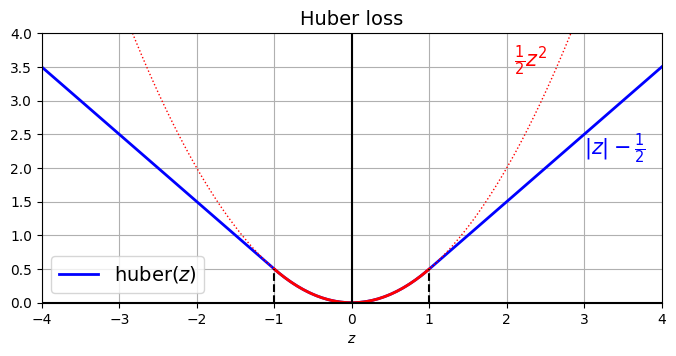

In [6]:
# extra code – shows what the Huber loss looks like

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
z = np.linspace(-4, 4, 200)
z_center = np.linspace(-1, 1, 200)
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")
plt.plot(z, z ** 2 / 2, "r:", linewidth=1)
plt.plot(z_center, z_center ** 2 / 2, "r", linewidth=2)
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "k--")
plt.plot([1, 1], [0, huber_fn(0., 1.)], "k--")
plt.gca().axhline(y=0, color='k')
plt.gca().axvline(x=0, color='k')
plt.text(2.1, 3.5, r"$\frac{1}{2}z^2$", color="r", fontsize=15)
plt.text(3.0, 2.2, r"$|z| - \frac{1}{2}$", color="b", fontsize=15)
plt.axis([-4, 4, 0, 4])
plt.grid(True)
plt.xlabel("$z$")
plt.legend(fontsize=14)
plt.title("Huber loss", fontsize=14)
plt.show()

In [5]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss  = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

In [4]:
# To test our custom loss function, let's create a basic Keras model and train it on the California housing dataset:
# extra code – loads, splits and scales the California housing dataset, then
#              creates a simple Keras model

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

input_shape = X_train.shape[1:]

tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 30)                  │             270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])

In [11]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4838 - mae: 0.8334 - val_loss: 0.3474 - val_mae: 0.6522
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2404 - mae: 0.5406 - val_loss: 0.2553 - val_mae: 0.5383


## Saving and Loading Models That Contain Custom Components

* **Saving models with custom loss**:

  * Works normally
  * While loading, must provide mapping:

    * `custom_objects = {"huber_fn": huber_fn}`

---

* Alternative (better):

  * Use decorator:

    * `@keras.utils.register_keras_serializable()`
  * Then no need for `custom_objects`

---

* Customizing Huber threshold:

  * Use function factory:

    * `create_huber(threshold)` → returns configured loss

* Issue:

  * Threshold value **not saved with model**
  * Must manually pass again while loading

---

* Solution: subclass **tf.keras.losses.Loss**

---

* Custom class structure:

  * Constructor:

    * Stores hyperparameters (e.g., threshold)
    * Calls parent constructor

  * call():

    * Computes loss per sample
    * Same Huber logic

  * get_config():

    * Returns dictionary of parameters:

      * `{ "threshold": value }`
    * Used for saving model

---

* Loss reduction:

  * Default:

    * `"SUM_OVER_BATCH_SIZE"`
  * Other options:

    * `"SUM"`
    * `"NONE"`

---

* Usage:

  * Compile:

    * `model.compile(loss=HuberLoss(2.0), optimizer="nadam")`

---

* Saving & loading:

  * Saving:

    * Keras stores config via `get_config()`

  * Loading:

    * `custom_objects = {"HuberLoss": HuberLoss}`
    * Internally uses:

      * `from_config(**config)`

---

* Key advantage:

  * Class-based loss:

    * **Hyperparameters are saved automatically**
    * Cleaner and reusable

---

* Key takeaway:

  * Function-based loss → simple but limited
  * Class-based loss → **production-ready + fully serializable**


In [12]:
model.save("my_model_with_a_custom_loss.keras")  # extra code – saving works fine

In [13]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss.keras",
                                   custom_objects={"huber_fn": huber_fn})

In [14]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2065 - mae: 0.4930 - val_loss: 0.2129 - val_mae: 0.4876
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1904 - mae: 0.4700 - val_loss: 0.1891 - val_mae: 0.4610


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 30)                  │             270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 605 (2.37 KB)

In [16]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = threshold * tf.abs(error) - threshold ** 2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

In [17]:
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=["mae"])

In [18]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2060 - mae: 0.4611 - val_loss: 0.2084 - val_mae: 0.4504
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1979 - mae: 0.4529 - val_loss: 0.1807 - val_mae: 0.4340


In [19]:
model.save("my_model_with_a_custom_loss_threshold_2.keras")

In [20]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_threshold_2.keras",
                                   custom_objects={"huber_fn": create_huber(2.0)})

In [21]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1927 - mae: 0.4468 - val_loss: 0.1853 - val_mae: 0.4339
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1887 - mae: 0.4414 - val_loss: 0.1976 - val_mae: 0.4367


In [22]:
class HuberLoss(tf.keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

In [23]:
# extra code – creates another basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [24]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])

In [25]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6461 - mae: 0.8446 - val_loss: 0.5086 - val_mae: 0.6718
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2899 - mae: 0.5544 - val_loss: 0.3527 - val_mae: 0.5571


In [26]:
model.save("my_model_with_a_custom_loss_class.keras")  # extra code – saving works

In [27]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_class.keras",
                                   custom_objects={"HuberLoss": HuberLoss})

In [28]:
# extra code – shows that loading worked fine, the model can be used normally
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2444 - mae: 0.5073 - val_loss: 0.2689 - val_mae: 0.4982
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2213 - mae: 0.4818 - val_loss: 0.2207 - val_mae: 0.4657


In [29]:
model.loss.threshold  # extra code – the treshold was loaded correctly

2.0

## Custom Activation Functions, Initializers, Regularizers, and Constraints

* **Keras customization scope**:

  * Can customize:

    * Losses
    * Regularizers
    * Constraints
    * Initializers
    * Metrics
    * Activation functions
    * Layers
    * Full models

---

* **Function-based customization (simple case)**:

  * Just define function with proper inputs/outputs

---

* Examples:

  * Activation (Softplus):

    * ( f(z) = \log(1 + e^z) )

  * Glorot initializer:

    * ( \sigma = \sqrt{\frac{2}{n_{in} + n_{out}}} )

  * L1 Regularization:

    * ( L = \sum |0.01 \cdot w| )

  * Positive weights constraint:

    * ( w = \max(0, w) )

---

* Usage in layer:

  * Custom functions passed as arguments:

    * activation
    * kernel_initializer
    * kernel_regularizer
    * kernel_constraint

---

* Training behavior:

  * Activation → applied to layer output
  * Initializer → sets initial weights
  * Regularizer → adds penalty to loss
  * Constraint → applied after each update

---

* When hyperparameters exist:

  * Use **class-based approach**

* Subclass from:

  * Regularizer → `tf.keras.regularizers.Regularizer`
  * Constraint → `tf.keras.constraints.Constraint`
  * Initializer → `tf.keras.initializers.Initializer`
  * Layer → `tf.keras.layers.Layer`

---

* Example (L1 Regularizer class):

  * Stores parameter:

    * factor
  * Computes:

    * ( \sum |factor \cdot w| )

---

* Required methods:

  * Loss / Layer / Model:

    * `call()`

  * Regularizer / Initializer / Constraint:

    * `__call__()`

  * For saving:

    * `get_config()` → returns parameters

---

* Key takeaway:

  * Function → quick & simple
  * Class → **needed for saving + reusable + configurable**


In [30]:
def my_softplus(z):
    return tf.math.log(1.0 + tf.exp(z))

def my_glorot_initializer(shape, dtype=tf.float32):
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights):  # return value is just tf.nn.relu(weights)
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

In [31]:
layer = tf.keras.layers.Dense(1, activation=my_softplus,
                              kernel_initializer=my_glorot_initializer,
                              kernel_regularizer=my_l1_regularizer,
                              kernel_constraint=my_positive_weights)

In [32]:
class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor

    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))

    def get_config(self):
        return {"factor": self.factor}

## Custom Metrics

* **Loss vs Metric (core difference)**:

  * **Loss**:

    * Used for **training (gradient descent)**
    * Must be **differentiable**
    * Gradients ≠ 0
    * Not necessarily human interpretable

  * **Metric**:

    * Used for **evaluation**
    * Can be **non-differentiable**
    * Should be **interpretable** (e.g., accuracy, precision)

---

* **Custom metric (basic case)**:

  * Same as custom loss → simple function works
  * Example:

    * Huber loss can be used as metric

---

* **Batch-wise issue (important)**:

  * Keras computes **mean of batch metrics**
  * This can give **wrong global result**

* Example (precision):

  * Batch 1:

    * ( \frac{4}{5} = 0.8 )

  * Batch 2:

    * ( \frac{0}{3} = 0.0 )

  * Mean:

    * ( \frac{0.8 + 0}{2} = 0.4 ) ❌

  * Actual precision:

    * ( \frac{4}{8} = 0.5 ) ✅

---

* Solution: **Streaming (stateful) metrics**

---

* Example: **tf.keras.metrics.Precision**

  * Tracks:

    * True positives
    * False positives
  * Computes correct global precision

---

* Behavior:

  * Called batch by batch
  * Updates internal state
  * Returns **cumulative metric**

---

* Important methods:

  * ( result() ) → current metric value
  * ( reset_states() ) → reset counters
  * variables → internal state (TP, FP, etc.)

---

* Custom streaming metric:

  * Subclass:

    * `tf.keras.metrics.Metric`

* Needs:

  * State variables (e.g., total loss, count)
  * Update logic (per batch)
  * Result computation

---

* Key takeaway:

  * Function metric → simple but may be **incorrect for global stats**
  * Stateful metric → **accurate across batches (production use)**


* **Custom streaming metric (HuberMetric)**:

  * Subclass of **tf.keras.metrics.Metric**
  * Tracks metric across batches (stateful)

---

* **Constructor (**init**)**:

  * Stores:

    * threshold
    * huber function
  * Creates state variables using:

    * ( total ) → sum of all losses
    * ( count ) → number of samples
  * Uses:

    * `add_weight()` → tracked automatically by Keras

---

* **update_state()**:

  * Called per batch
  * Steps:

    * Compute sample-wise Huber loss
    * ( total += \sum loss )
    * ( count += \text{number of samples} )

---

* **result()**:

  * Returns final metric:

    * ( \frac{total}{count} )
  * Represents **mean Huber loss over all batches**

---

* **get_config()**:

  * Saves hyperparameters:

    * threshold
  * Ensures proper model serialization

---

* **reset_states()**:

  * Resets:

    * ( total = 0 )
    * ( count = 0 )
  * Default behavior (no need to override usually)

---

* **Execution flow**:

  * When metric is called:

    1. `update_state()` runs
    2. `result()` returns value

---

* **Key insights**:

  * Function metric → averaged per batch
  * Class metric → **true global metric across batches**

---

* **When to use class-based metrics**:

  * When metric depends on **cumulative statistics**:

    * Precision
    * Recall
    * F1-score
    * Custom aggregated metrics

---

* **Key takeaway**:

  * Streaming metrics = **accurate + stateful + production-ready**
  * Same pattern as custom loss, but with **state tracking across batches**


In [33]:
# extra code – once again, lets' create a basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [34]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])

In [35]:
# extra code – train the model with our custom metric
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - huber_fn: 0.6814 - loss: 1.7395
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_fn: 0.3131 - loss: 0.7699


**Note**: if you use the same function as the loss and a metric, you may be surprised to see slightly different results. This is in part because the operations are not computed exactly in the same order, so there might be tiny floating point errors. More importantly, if you use sample weights or class weights, then the equations are a bit different:
* the `fit()` method keeps track of the mean of all batch losses seen so far since the start of the epoch. Each batch loss is the sum of the weighted instance losses divided by the _batch size_ (not the sum of weights, so the batch loss is _not_ the weighted mean of the losses).
* the metric since the start of the epoch is equal to the sum of weighted instance losses divided by sum of all weights seen so far. In other words, it is the weighted mean of all the instance losses. Not the same thing.

In [36]:
precision = tf.keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>

In [37]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [38]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [39]:
precision.variables

[<Variable path=precision/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision/false_positives, shape=(1,), dtype=float32, value=[4.]>]

In [40]:
precision.reset_state()

**Warning**: the `add_weight()` method's argument have a different order now, so we have to specify `name="total"` and `name="count"` rather than just passing the name as the first argument.

In [41]:
class HuberMetric(tf.keras.metrics.Metric):
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs)  # handles base args (e.g., dtype)
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        sample_metrics = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(sample_metrics))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total / self.count

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

**Extra material** – the rest of this section tests the `HuberMetric` class and shows another implementation subclassing `tf.keras.metrics.Mean`.

In [42]:
m = HuberMetric(2.)

# total = 2 * |10 - 2| - 2²/2 = 14
# count = 1
# result = 14 / 1 = 14
m(tf.constant([[2.]]), tf.constant([[10.]]))

<tf.Tensor: shape=(), dtype=float32, numpy=14.0>

In [43]:
# total = total + (|1 - 0|² / 2) + (2 * |9.25 - 5| - 2² / 2) = 14 + 7 = 21
# count = count + 2 = 3
# result = total / count = 21 / 3 = 7
m(tf.constant([[0.], [5.]]), tf.constant([[1.], [9.25]]))

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [44]:
m.result()

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [45]:
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=21.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=3.0>]

In [46]:
m.reset_state()
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=0.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=0.0>]

In [47]:
# Let's check that the `HuberMetric` class works well:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [48]:
model.compile(loss=create_huber(2.0), optimizer="nadam",
              metrics=[HuberMetric(2.0)])

In [49]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - huber_metric_1: 0.6461 - loss: 0.6461
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_metric_1: 0.2899 - loss: 0.2899


In [50]:
model.save("my_model_with_a_custom_metric.keras")

In [51]:
model = tf.keras.models.load_model(
    "my_model_with_a_custom_metric.keras",
    custom_objects={
        "huber_fn": create_huber(2.0),
        "HuberMetric": HuberMetric
    }
)

In [52]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - huber_metric_1: 0.2444 - loss: 0.2444
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber_metric_1: 0.2213 - loss: 0.2213


In [53]:
# Looks like it works fine! More simply, we could have created the class like this:
class HuberMetric(tf.keras.metrics.Mean):
    def __init__(self, threshold=1.0, name='HuberMetric', dtype=None):
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        super().__init__(name=name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        metric = self.huber_fn(y_true, y_pred)
        super(HuberMetric, self).update_state(metric, sample_weight)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}        

In [54]:
# This class handles shapes better, and it also supports sample weights.
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

In [55]:
model.compile(loss=tf.keras.losses.Huber(2.0), optimizer="nadam",
              weighted_metrics=[HuberMetric(2.0)])

In [56]:
np.random.seed(42)
sample_weight = np.random.rand(len(y_train))
history = model.fit(X_train_scaled, y_train, epochs=2,
                    sample_weight=sample_weight)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - HuberMetric: 0.6563 - loss: 0.3257
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - HuberMetric: 0.2907 - loss: 0.1443


In [57]:
(history.history["loss"][0],
 history.history["HuberMetric"][0] * sample_weight.mean())

(0.3256884217262268, np.float64(0.32568849524955656))

In [58]:
model.save("my_model_with_a_custom_metric_v2.keras")

In [59]:
model = tf.keras.models.load_model("my_model_with_a_custom_metric_v2.keras",
                                   custom_objects={"HuberMetric": HuberMetric})

In [60]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - HuberMetric: 0.2436 - loss: 0.2113
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - HuberMetric: 0.2179 - loss: 0.1909


## Custom Layers

* **When to build custom layers**:

  * When required layer **does not exist in TensorFlow**
  * When repeating a **block of layers multiple times**

---

* **Stateless custom layer (no weights)**:

  * Use **Lambda layer**:

    * `tf.keras.layers.Lambda()`
  * Example:

    * ( f(x) = e^x )
  * Can be used:

    * As layer
    * As activation

---

* Use case:

  * Exponential activation useful when:

    * Output values have **very different scales**

---

* **Stateful custom layer (with weights)**:

  * Subclass **tf.keras.layers.Layer**

---

* **Structure of custom layer**:

  * ****init**()**:

    * Define hyperparameters (units, activation)
    * Accept **kwargs → pass to parent
    * Convert activation:

      * `tf.keras.activations.get()`

---

* **build(input_shape)**:

  * Create weights using:

    * `add_weight()`
  * Example:

    * Kernel:

      * shape = ( (input_features, units) )
    * Bias:

      * shape = ( (units) )
  * Called automatically on first use

---

* **call(X)**:

  * Defines forward pass:

    * ( XW + b )
    * Apply activation

---

* **get_config()**:

  * Save hyperparameters
  * Serialize activation:

    * `tf.keras.activations.serialize()`

---

* **Key concepts**:

  * build() → create weights
  * call() → define computation
  * add_weight() → tracked variables

---

* **Execution flow**:

  1. Layer initialized
  2. First call → build() runs
  3. call() executes forward pass

---

* **Output shape**:

  * Usually inferred automatically
  * If dynamic:

    * Implement `compute_output_shape()`

---

* **Key takeaway**:

  * Lambda → quick stateless layer
  * Subclass Layer → **full control (custom architectures)**


* **Multiple inputs layer**:

  * `call()` receives inputs as **tuple/list**
  * Example:

    * ( X = (X_1, X_2) )

---

* **Multiple outputs layer**:

  * `call()` returns **tuple/list of outputs**
  * Example:

    * Outputs:

      * ( X_1 + X_2 )
      * ( X_1 \cdot X_2 )
      * ( \frac{X_1}{X_2} )

---

* **API limitation**:

  * Works with:

    * Functional API
    * Subclassing API
  * ❌ Not supported in Sequential API

---

* **Training vs Inference behavior**:

  * Add argument:

    * `training=False` in `call()`

---

* Example: Gaussian Noise Layer

  * During training:

    * Add noise:

      * ( X + \mathcal{N}(0, \sigma^2) )

  * During testing:

    * Return:

      * ( X ) (no change)

---

* Implementation logic:

  * If `training=True`:

    * Apply noise
  * Else:

    * Pass input unchanged

---

* Use case:

  * Regularization
  * Prevent overfitting

---

* Key takeaway:

  * Multi-input/output → handled via tuples/lists
  * training flag → controls behavior dynamically
  * Enables **advanced custom architectures + behaviors**


In [62]:
exponential_layer = tf.keras.layers.Lambda(lambda x: tf.exp(x))

In [63]:
# extra code – like all layers, it can be used as a function:
exponential_layer(tf.constant([-1., 0., 1.]))

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.36787945, 1.        , 2.7182817 ], dtype=float32)>

In [64]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", input_shape=input_shape),
    tf.keras.layers.Dense(1),
    exponential_layer
])
model.compile(loss="mse", optimizer="sgd")
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)


Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7784 - val_loss: 0.4393
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4889 - val_loss: 0.4048
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4824 - val_loss: 0.3942
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4105 - val_loss: 0.3699
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4378 - val_loss: 0.3756
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3936


0.39363133907318115

In [65]:
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],
            initializer="he_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")

    def call(self, X):
        return self.activation(X @ self.kernel + self.bias)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": tf.keras.activations.serialize(self.activation)}

In [66]:
# extra code – shows that a custom layer can be used normally
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    MyDense(30, activation="relu", input_shape=input_shape),
    MyDense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)
model.save("my_model_with_a_custom_layer.keras")

Epoch 1/2


C:\Users\roush\AppData\Local\Temp\ipykernel_16728\3097604586.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.0949 - val_loss: 6.9255
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8668 - val_loss: 2.6011
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7037


In [67]:
# extra code – shows how to load a model with a custom layer
model = tf.keras.models.load_model("my_model_with_a_custom_layer.keras",
                                   custom_objects={"MyDense": MyDense})
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6481 - val_loss: 0.8613
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5347 - val_loss: 0.4588


In [68]:
class MyMultiLayer(tf.keras.layers.Layer):
    def call(self, X):
        X1, X2 = X
        print("X1.shape: ", X1.shape ," X2.shape: ", X2.shape)  # extra code
        return X1 + X2, X1 * X2, X1 / X2

In [69]:
# extra code – tests MyMultiLayer with symbolic inputs
inputs1 = tf.keras.layers.Input(shape=[2])
inputs2 = tf.keras.layers.Input(shape=[2])
MyMultiLayer()((inputs1, inputs2))

X1.shape:  (None, 2)  X2.shape:  (None, 2)


(<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_44>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_45>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>)

Note that the `call()` method receives symbolic inputs, and it returns symbolic outputs. The shapes are only partially specified at this stage: we don't know the batch size, which is why the first dimension is `None`.

We can also pass actual data to the custom layer:`

In [70]:
# extra code – tests MyMultiLayer with actual data 
X1, X2 = np.array([[3., 6.], [2., 7.]]), np.array([[6., 12.], [4., 3.]]) 
MyMultiLayer()((X1, X2))

X1.shape:  (2, 2)  X2.shape:  (2, 2)


(<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[ 9., 18.],
        [ 6., 10.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[18., 72.],
        [ 8., 21.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[0.5      , 0.5      ],
        [0.5      , 2.3333333]], dtype=float32)>)

In [71]:
class MyGaussianNoise(tf.keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, X, training=None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X

In [72]:
# extra code – tests MyGaussianNoise
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    MyGaussianNoise(stddev=1.0, input_shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2


C:\Users\roush\AppData\Local\Temp\ipykernel_16728\3716225758.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.2156 - val_loss: 25.1369
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4081 - val_loss: 14.9793
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1244


1.1244221925735474

## Custom Models

* **Custom model creation**:

  * Subclass **tf.keras.Model**
  * Steps:

    * Define layers in `__init__()`
    * Define forward pass in `call()`

---

* **Residual Block concept**:

  * Applies multiple layers
  * Adds input back to output:

    * ( output = input + F(input) )
  * Called **skip connection**

---

* **ResidualBlock layer**:

  * Contains multiple Dense layers
  * Forward flow:

    * Pass input through layers → ( Z )
    * Add original input:

      * ( input + Z )

* Important:

  * Keras automatically tracks:

    * Inner layers
    * Their weights

---

* **Custom model (ResidualRegressor)**:

  * Architecture:

    1. Input → Dense layer
    2. Repeated ResidualBlock (loop)
    3. Another ResidualBlock
    4. Output Dense layer

---

* **Loop inside model**:

  * Same block reused multiple times:

    * Improves modularity
    * Shows flexibility of subclassing API

---

* **Usage**:

  * Same as standard models:

    * `compile()`
    * `fit()`
    * `evaluate()`
    * `predict()`

---

* **Saving models**:

  * For full model saving:

    * Implement `get_config()` in:

      * Block class
      * Model class

  * Alternative:

    * Save only weights:

      * `save_weights()` / `load_weights()`

---

* **Model vs Layer**:

  * Model ⊂ Layer (Model inherits Layer)
  * Difference:

    * Layer → building block
    * Model → trainable system

---

* **Extra model features**:

  * `compile()`
  * `fit()`
  * `evaluate()`
  * `predict()`
  * `get_layer()`
  * `save()` / `load_model()`

---

* **Best practice**:

  * Use:

    * Layer → reusable components
    * Model → full architecture

---

* **Key takeaway**:

  * Subclassing API = **maximum flexibility**
  * Can build:

    * Custom architectures
    * Loops
    * Skip connections
    * Complex research-level models


In [73]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(n_layers)]

    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        return inputs + Z

In [74]:
class ResidualRegressor(tf.keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.hidden1 = tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
        self.block1 = ResidualBlock(2, 30)
        self.block2 = ResidualBlock(2, 30)
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, inputs):
        Z = self.hidden1(inputs)
        for _ in range(1 + 3):
            Z = self.block1(Z)
        Z = self.block2(Z)
        return self.out(Z)

    # extra code - to be able to save and load the model below
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "output_dim": self.output_dim}

In [75]:
# extra code – shows that the model can be used normally
tf.keras.utils.set_random_seed(42)
model = ResidualRegressor(1)
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=2)
score = model.evaluate(X_test_scaled, y_test)
model.save("my_custom_model.keras")

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 29.9859 
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4475
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1709


In [76]:
# extra code – the model can be loaded and you can continue training or use it
#              to make predictions
model = tf.keras.models.load_model(
    "my_custom_model.keras",
    custom_objects={"ResidualRegressor": ResidualRegressor}
)
history = model.fit(X_train_scaled, y_train, epochs=2)
model.predict(X_test_scaled[:3])

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9944
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


array([[0.7005741],
       [1.111657 ],
       [3.8891034]], dtype=float32)

In [77]:
tf.keras.utils.set_random_seed(42)
block1 = ResidualBlock(2, 30)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    block1, block1, block1, block1,
    ResidualBlock(2, 30),
    tf.keras.layers.Dense(1)
])

## Losses and Metrics Based on Model Internals

* **Custom losses from model internals**:

  * Not limited to ( y_{true}, y_{pred} )
  * Can use:

    * Weights
    * Hidden activations
  * Useful for:

    * Regularization
    * Monitoring internal behavior

---

* **add_loss()**:

  * Add custom loss inside model:

    * ( \text{total loss} = \text{main loss} + \text{custom loss} )

---

* **Example: Reconstruction loss**:

  * Idea:

    * Reconstruct input from hidden representation
  * Formula:

    * ( L_{recon} = \text{mean}((X_{recon} - X)^2) )

---

* **Purpose**:

  * Encourage model to:

    * Preserve information in hidden layers
  * Improves:

    * Generalization

---

* **Model structure**:

  * 5 hidden layers
  * Output layer
  * Extra reconstruction layer

---

* **build() method**:

  * Creates reconstruction layer
  * Needed because:

    * Input size unknown before build

---

* **call() flow**:

  1. Input → hidden layers → ( Z )
  2. ( Z \rightarrow ) reconstruction layer → ( X_{recon} )
  3. Compute reconstruction loss
  4. Add loss:

     * ( \text{add_loss}(0.05 \cdot L_{recon}) )
  5. Return final output

---

* **Scaling factor (important)**:

  * ( 0.05 \cdot L_{recon} )
  * Prevents auxiliary loss dominating main loss

---

* **Custom metric (add_metric())**:

  * Tracks reconstruction error
  * Uses:

    * Streaming metric (Mean)

* Shortcut:

  * `add_metric(recon_loss)` → auto mean tracking

---

* **Training behavior**:

  * Both losses decrease:

    * Main loss
    * Reconstruction loss

---

* **Key takeaway**:

  * add_loss() → inject **internal constraints into training**
  * Enables:

    * Multi-objective learning
    * Regularization via model structure

---

* **Next concept hint**:

  * For advanced models (e.g., GANs):

    * Need **custom training loops**
    * Requires manual gradient handling


In [78]:
class ReconstructingRegressor(tf.keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(5)]
        self.out = tf.keras.layers.Dense(output_dim)

    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = tf.keras.layers.Dense(n_inputs)

    def call(self, inputs, training=None):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * recon_loss)
        return self.out(Z)

In [79]:
# extra code
tf.keras.utils.set_random_seed(42)
model = ReconstructingRegressor(1)
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=5)
y_pred = model.predict(X_test_scaled)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7571
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5037
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4193
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4187
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3708
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Computing Gradients Using Autodiff

### Appendix B. Autodiff

* **Autodifferentiation (Autodiff)** in TensorFlow:

  * Automatically computes **gradients (derivatives)**
  * Essential for:

    * Gradient descent
    * Model training

---

* Example function:

  * ( f(x, y) = xy + y + 2 )

---

* Required:

  * Partial derivatives:

    * ( \frac{\partial f}{\partial x} )
    * ( \frac{\partial f}{\partial y} )

---

* Methods to compute derivatives:

---

* **1. Manual differentiation**:

  * Solve mathematically:

    * ( \frac{\partial f}{\partial x} = y )
    * ( \frac{\partial f}{\partial y} = x + 1 )
  * Pros:

    * Exact
  * Cons:

    * Error-prone
    * Not scalable for deep networks

---

* **2. Finite difference approximation**:

  * Approximate derivative:

    * ( \frac{\partial f}{\partial x} \approx \frac{f(x+\epsilon, y) - f(x, y)}{\epsilon} )
  * Pros:

    * Simple
  * Cons:

    * Slow
    * Numerical instability
    * Approximation error

---

* **3. Forward-mode autodiff**:

  * Computes derivatives **along with forward pass**
  * Efficient when:

    * Few inputs, many outputs

---

* **4. Reverse-mode autodiff (used by TensorFlow)**:

  * Computes gradients **backward from output to inputs**
  * Efficient when:

    * Many inputs (parameters), one output (loss)

---

* **Why reverse-mode is ideal for ML**:

  * Neural networks:

    * Thousands/millions of parameters
    * Single loss value
  * Reverse-mode computes all gradients **in one backward pass**

---

* **Key takeaway**:

  * TensorFlow uses **reverse-mode autodiff = backpropagation engine**
  * This is what powers:

    * Training
    * Optimization
    * Deep learning itself 🚀


#### Manual Differentiation

* **Manual differentiation (first approach)**:

  * Use calculus rules to compute derivatives by hand
  * Works for simple functions, but not scalable

---

* Example function:

  * ( f(x, y) = x^2 y + y + 2 )

---

* **Basic derivative rules used**:

  * Constant:

    * ( $\frac{d}{dx}(c) = 0$ )

  * Linear:

    * ( $\frac{d}{dx}(\lambda x) = \lambda$ )

  * Power rule:

    * ( $\frac{d}{dx}(x^n) = n x^{n-1}$ )

  * Sum rule:

    * ( $\frac{d}{dx}(f + g) = f' + g'$ )

  * Constant multiple:

    * ( $\frac{d}{dx}(\lambda f) = \lambda f'$ )

---

* **Partial derivatives**:

  * With respect to ( x ):

    * ( $\frac{\partial f}{\partial x} = 2xy )$

  * With respect to ( y ):

    * ( $\frac{\partial f}{\partial y} = x^2 + 1$ )

---

* **Process insight**:

  * Treat other variables as constants while differentiating

---

* **Limitations**:

  * Becomes:

    * Tedious
    * Error-prone
    * Hard for complex neural networks

---

* **Key takeaway**:

  * Manual differentiation = **foundation concept**
  * Not practical for deep learning → leads to need for **autodiff methods**


#### Finite Difference Approximation

* **Derivative definition (core idea)**:

  * Derivative = **slope of function at a point**
  * Formula:

    * ( $h'(x_0) = \lim_{\epsilon \to 0} \frac{h(x_0 + \epsilon) - h(x_0)}{\epsilon}$ )

---

* **Finite Difference Approximation**:

  * Replace limit with small ( $\epsilon$ )
  * Approximation:

    * ( $\frac{\partial f}{\partial x} \approx \frac{f(x+\epsilon, y) - f(x, y)}{\epsilon}$ )

---

* Example:

  * ( $f(x,y) = x^2 y + y + 2$ )

  * At ( x=3, y=4 )

  * True values:

    * ( $\frac{\partial f}{\partial x} = 2xy = 24$ )
    * ( $\frac{\partial f}{\partial y} = x^2 + 1 = 10$ )

---

* **Approximation results**:

  * Slight errors due to:

    * Floating-point precision
    * Approximation nature

---

* **Efficiency problem**:

  * For ( n ) parameters:

    * Need ( n+1 ) function evaluations
  * Example:

    * 1000 parameters → 1001 evaluations

---

* **Drawbacks**:

  * Computationally expensive
  * Not scalable for deep learning
  * Numerical instability

---

* **Advantage**:

  * Very simple to implement
  * Useful for:

    * Debugging gradients
    * Verifying correctness

---

* **Key takeaway**:

  * Finite difference = **good for checking**, not for training
  * Leads to need for:

    * **Autodiff (efficient + exact gradients)**


In [5]:
def f(x,y):
    return x*x*y + y + 2

In [6]:
def df(x,y):
    return 2*x*y, x*x + 1

In [7]:
df(3, 4)

(24, 10)

Perfect! We can also find the equations for the second order derivatives (also called Hessians):

$\dfrac{\partial^2 f}{\partial x \partial x} = \dfrac{\partial (2xy)}{\partial x} = 2y$

$\dfrac{\partial^2 f}{\partial x \partial y} = \dfrac{\partial (2xy)}{\partial y} = 2x$

$\dfrac{\partial^2 f}{\partial y \partial x} = \dfrac{\partial (x^2 + 1)}{\partial x} = 2x$

$\dfrac{\partial^2 f}{\partial y \partial y} = \dfrac{\partial (x^2 + 1)}{\partial y} = 0$

In [8]:
def d2f(x, y):
    return [2*y, 2*x], [2*x, 0]

In [9]:
d2f(3, 4)

([8, 6], [6, 0])

In [10]:
def gradients(func, vars_list, eps=0.0001):
    partial_derivatives = []
    base_func_eval = func(*vars_list)
    for idx in range(len(vars_list)):
        tweaked_vars = vars_list[:]
        tweaked_vars[idx] += eps
        tweaked_func_eval = func(*tweaked_vars)
        derivative = (tweaked_func_eval - base_func_eval) / eps
        partial_derivatives.append(derivative)
    return partial_derivatives

In [11]:
def df(x, y):
    return gradients(f, [x, y])

In [12]:
df(3, 4)

[24.000400000048216, 10.000000000047748]

In [13]:
def dfdx(x, y):
    return gradients(f, [x,y])[0]

def dfdy(x, y):
    return gradients(f, [x,y])[1]

dfdx(3., 4.), dfdy(3., 4.)

(24.000400000048216, 10.000000000047748)

In [14]:
def d2f(x, y):
    return [gradients(dfdx, [x, y]), gradients(dfdy, [x, y])]

In [15]:
d2f(3, 4)

[[7.999999951380232, 6.000099261882497],
 [6.000099261882497, -1.4210854715202004e-06]]

Rather than this numerical approach, let's implement some symbolic autodiff techniques. For this, we will need to define classes to represent constants, variables and operations.

In [16]:
class Const(object):
    def __init__(self, value):
        self.value = value
    def evaluate(self):
        return self.value
    def __str__(self):
        return str(self.value)

class Var(object):
    def __init__(self, name, init_value=0):
        self.value = init_value
        self.name = name
    def evaluate(self):
        return self.value
    def __str__(self):
        return self.name

class BinaryOperator(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b

class Add(BinaryOperator):
    def evaluate(self):
        return self.a.evaluate() + self.b.evaluate()
    def __str__(self):
        return "{} + {}".format(self.a, self.b)

class Mul(BinaryOperator):
    def evaluate(self):
        return self.a.evaluate() * self.b.evaluate()
    def __str__(self):
        return "({}) * ({})".format(self.a, self.b)

In [17]:
x = Var("x")
y = Var("y")
f = Add(Mul(Mul(x, x), y), Add(y, Const(2))) # f(x,y) = x²y + y + 2

In [18]:
x.value = 3
y.value = 4
f.evaluate()

42

The autodiff methods we will present below are all based on the *chain rule*.

Suppose we have two functions $u$ and $v$, and we apply them sequentially to some input $x$, and we get the result $z$. So we have $z = v(u(x))$, which we can rewrite as $z = v(s)$ and $s = u(x)$. Now we can apply the chain rule to get the partial derivative of the output $z$ with regards to the input $x$:

$ \dfrac{\partial z}{\partial x} = \dfrac{\partial s}{\partial x} \cdot \dfrac{\partial z}{\partial s}$

Now if $z$ is the output of a sequence of functions which have intermediate outputs $s_1, s_2, ..., s_n$, the chain rule still applies:

$ \dfrac{\partial z}{\partial x} = \dfrac{\partial s_1}{\partial x} \cdot \dfrac{\partial s_2}{\partial s_1} \cdot \dfrac{\partial s_3}{\partial s_2} \cdot \dots \cdot \dfrac{\partial s_{n-1}}{\partial s_{n-2}} \cdot \dfrac{\partial s_n}{\partial s_{n-1}} \cdot \dfrac{\partial z}{\partial s_n}$

In forward mode autodiff, the algorithm computes these terms "forward" (i.e., in the same order as the computations required to compute the output $z$), that is from left to right: first $\dfrac{\partial s_1}{\partial x}$, then $\dfrac{\partial s_2}{\partial s_1}$, and so on. In reverse mode autodiff, the algorithm computes these terms "backwards", from right to left: first $\dfrac{\partial z}{\partial s_n}$, then $\dfrac{\partial s_n}{\partial s_{n-1}}$, and so on.

For example, suppose you want to compute the derivative of the function $z(x)=\sin(x^2)$ at x=3, using forward mode autodiff. The algorithm would first compute the partial derivative $\dfrac{\partial s_1}{\partial x}=\dfrac{\partial x^2}{\partial x}=2x=6$. Next, it would compute $\dfrac{\partial z}{\partial x}=\dfrac{\partial s_1}{\partial x}\cdot\dfrac{\partial z}{\partial s_1}= 6 \cdot \dfrac{\partial \sin(s_1)}{\partial s_1}=6 \cdot \cos(s_1)=6 \cdot \cos(3^2)\approx-5.46$.

In [20]:
from math import sin

def z(x):
    return sin(x**2)

gradients(z, [3])

[-5.46761419430053]

#### Forward-Mode Autodiff

* **Forward-mode autodiff**:

  * Computes derivatives **along with forward pass**
  * Moves from **inputs → outputs**

---

* Example function:

  * ( $g(x, y) = 5 + xy$ )

---

* Goal:

  * Compute:

    * ( $\frac{\partial g}{\partial x}$ )

---

* **Step 1: Leaf node derivatives**:

  * Constant:

    * ( $\frac{\partial 5}{\partial x} = 0$ )
  * Variable ( x ):

    * ( $\frac{\partial x}{\partial x} = 1$ )
  * Variable ( y ):

    * ( $\frac{\partial y}{\partial x} = 0$ )

---

* **Step 2: Multiplication rule**:

  * ($ \frac{\partial (u \cdot v)}{\partial x} = \frac{\partial v}{\partial x} \cdot u + v \cdot \frac{\partial u}{\partial x} $)

  * Apply:

    * ($ \frac{\partial (xy)}{\partial x} = 0 \cdot x + y \cdot 1$ )

---

* **Step 3: Addition rule**:

  * ($ \frac{\partial (5 + xy)}{\partial x} = 0 + (0 \cdot x + y \cdot 1) $)

---

* **Final simplified result**:

  * ( $\frac{\partial g}{\partial x} = y$ )

---

* **Graph-based computation**:

  * Forward-mode builds a **new computation graph for derivatives**
  * Then simplifies it

---

* **Symbolic differentiation advantages**:

  * Once graph is built:

    * Can reuse it for any inputs
  * Can compute:

    * Second-order derivatives
    * Higher-order derivatives

---

* **Limitations**:

  * Graph can become:

    * Large
    * Complex
  * Hard to optimize for big models

---

* **Key takeaway**:

  * Forward-mode = **input-to-output derivative propagation**
  * Efficient for:

    * Few inputs
  * Not ideal for deep learning → leads to **reverse-mode autodiff**


* **Forward-mode autodiff (numeric version)**:

  * Can compute derivatives **without building a graph**
  * Uses **dual numbers**

---

* **Dual numbers**:

  * Form:

    * ( $a + b\epsilon$ )
  * Where:

    * $( \epsilon^2 = 0 )$, but $( \epsilon \neq 0 )$
  * Representation:

    * Pair of floats:

      * ( (a, b) )

---

* **Operations with dual numbers**:

  * Scalar multiply:

    * ( $\lambda(a + b\epsilon) = \lambda a + \lambda b\epsilon$ )

  * Addition:

    * ( $(a + b\epsilon) + (c + d\epsilon) = (a+c) + (b+d)\epsilon$ )

  * Multiplication:

    * ( $(a + b\epsilon)(c + d\epsilon) = ac + (ad + bc)\epsilon$ )

---

* **Key property (important)**:

  * ( $h(a + b\epsilon) = h(a) + b \cdot h'(a)\epsilon$ )

---

* **Main idea**:

  * Compute:

    * ( $h(a + \epsilon)$ )
  * Result gives:

    * Real part → ( h(a) )
    * ( $\epsilon$ ) part → ( h'(a) )

---

* **Example usage**:

  * To compute:

    * ( $\frac{\partial f}{\partial x}(3,4)$ )

  * Evaluate:

    * ( f(3 + $\epsilon$, 4) )

  * Output:

    * First part → ( f(3,4) )
    * Second part → derivative

---

* **For other variables**:

  * Need separate pass:

    * ( f(3, 4 + $\epsilon$) ) → gives ( $\frac{\partial f}{\partial y}$ )

---

* **Advantages**:

  * More accurate than finite differences
  * No approximation error

---

* **Limitation (critical)**:

  * For ( n ) inputs:

    * Requires **n passes**
  * Example:

    * 1000 parameters → 1000 passes

---

* **Key takeaway**:

  * Forward-mode + dual numbers = **exact derivatives efficiently (per input)**
  * Not suitable for deep learning → too many parameters

---

* **Why we need next step**:

  * Reverse-mode autodiff:

    * Computes **all gradients in ~2 passes**
    * Perfect for neural networks 🚀


In [21]:
Const.gradient = lambda self, var: Const(0)
Var.gradient = lambda self, var: Const(1) if self is var else Const(0)
Add.gradient = lambda self, var: Add(self.a.gradient(var), self.b.gradient(var))
Mul.gradient = lambda self, var: Add(Mul(self.a, self.b.gradient(var)), Mul(self.a.gradient(var), self.b))

x = Var(name="x", init_value=3.)
y = Var(name="y", init_value=4.)
f = Add(Mul(Mul(x, x), y), Add(y, Const(2))) # f(x,y) = x²y + y + 2

dfdx = f.gradient(x)  # 2xy
dfdy = f.gradient(y)  # x² + 1

In [22]:
dfdx.evaluate(), dfdy.evaluate()

(24.0, 10.0)

In [23]:
d2fdxdx = dfdx.gradient(x) # 2y
d2fdxdy = dfdx.gradient(y) # 2x
d2fdydx = dfdy.gradient(x) # 2x
d2fdydy = dfdy.gradient(y) # 0

In [24]:
[[d2fdxdx.evaluate(), d2fdxdy.evaluate()],
 [d2fdydx.evaluate(), d2fdydy.evaluate()]]

[[8.0, 6.0], [6.0, 0.0]]

In [25]:
class DualNumber(object):
    def __init__(self, value=0.0, eps=0.0):
        self.value = value
        self.eps = eps
    def __add__(self, b):
        return DualNumber(self.value + self.to_dual(b).value,
                          self.eps + self.to_dual(b).eps)
    def __radd__(self, a):
        return self.to_dual(a).__add__(self)
    def __mul__(self, b):
        return DualNumber(self.value * self.to_dual(b).value,
                          self.eps * self.to_dual(b).value + self.value * self.to_dual(b).eps)
    def __rmul__(self, a):
        return self.to_dual(a).__mul__(self)
    def __str__(self):
        if self.eps:
            return "{:.1f} + {:.1f}ε".format(self.value, self.eps)
        else:
            return "{:.1f}".format(self.value)
    def __repr__(self):
        return str(self)
    @classmethod
    def to_dual(cls, n):
        if hasattr(n, "value"):
            return n
        else:
            return cls(n)

In [26]:
3 + DualNumber(3, 4)

6.0 + 4.0ε

In [27]:
DualNumber(3, 4) * DualNumber(5, 7)

15.0 + 41.0ε

In [28]:
x.value = DualNumber(3.0)
y.value = DualNumber(4.0)

f.evaluate()

42.0

In [29]:
x.value = DualNumber(3.0, 1.0)  # 3 + ε
y.value = DualNumber(4.0)       # 4

dfdx = f.evaluate().eps

x.value = DualNumber(3.0)       # 3
y.value = DualNumber(4.0, 1.0)  # 4 + ε

dfdy = f.evaluate().eps

In [30]:
dfdx

24.0

In [31]:
dfdy

10.0

#### Reverse-Mode Autodiff

* **Reverse-mode autodiff (used by TensorFlow)**:

  * Two passes:

    1. **Forward pass** → compute all node values
    2. **Backward pass** → compute gradients

---

* **Core idea**:

  * Gradients flow **from output → inputs**
  * Uses **chain rule**:

    * ( $\frac{\partial f}{\partial x} = \frac{\partial f}{\partial n_i} \cdot \frac{\partial n_i}{\partial x}$ )

---

* **Process**:

  * Start from output:

    * ( $\frac{\partial f}{\partial f}$ = 1 )

  * Move backward through graph:

    * At each node:

      * Compute gradient contribution
      * Pass it to previous nodes

---

* **Example result** (for ( f(x,y)=x^2y + y + 2 )):

  * ( $\frac{\partial f}{\partial x} = 24$ )
  * ( $\frac{\partial f}{\partial y} = 10$ )

---

* **Why it is powerful**:

  * For **n inputs, 1 output**:

    * Only **2 passes needed**

      * 1 forward
      * 1 backward

* Compare:

  * Forward-mode:

    * Needs **n passes** ❌
  * Reverse-mode:

    * Needs **1 backward pass** ✅

---

* **Perfect for deep learning**:

  * Neural networks:

    * Many parameters (inputs)
    * Single loss (output)

---

* **Handles non-perfect differentiability**:

  * Works as long as:

    * Point is differentiable

---

* **TensorFlow implementation**:

  * Uses **symbolic reverse-mode autodiff**:

    * Builds computation graph for gradients
    * Reuses it efficiently

---

* **Benefits of symbolic approach**:

  * Graph built once → reused many times
  * Supports:

    * Higher-order derivatives

---

* **Important note (custom ops)**:

  * If defining custom operation:

    * Must define derivative:

      * Example:

        * ($ f(x)=x^2 \Rightarrow f'(x)=2x $)

---

* **Key takeaway**:

  * Reverse-mode autodiff = **backpropagation engine**
  * Core reason deep learning is computationally feasible 🚀


In [32]:
class Const(object):
    def __init__(self, value):
        self.value = value
    def evaluate(self):
        return self.value
    def backpropagate(self, gradient):
        pass
    def __str__(self):
        return str(self.value)

class Var(object):
    def __init__(self, name, init_value=0):
        self.value = init_value
        self.name = name
        self.gradient = 0
    def evaluate(self):
        return self.value
    def backpropagate(self, gradient):
        self.gradient += gradient
    def __str__(self):
        return self.name

class BinaryOperator(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b

class Add(BinaryOperator):
    def evaluate(self):
        self.value = self.a.evaluate() + self.b.evaluate()
        return self.value
    def backpropagate(self, gradient):
        self.a.backpropagate(gradient)
        self.b.backpropagate(gradient)
    def __str__(self):
        return "{} + {}".format(self.a, self.b)

class Mul(BinaryOperator):
    def evaluate(self):
        self.value = self.a.evaluate() * self.b.evaluate()
        return self.value
    def backpropagate(self, gradient):
        self.a.backpropagate(gradient * self.b.value)
        self.b.backpropagate(gradient * self.a.value)
    def __str__(self):
        return "({}) * ({})".format(self.a, self.b)

In [33]:
x = Var("x", init_value=3)
y = Var("y", init_value=4)
f = Add(Mul(Mul(x, x), y), Add(y, Const(2))) # f(x,y) = x²y + y + 2

result = f.evaluate()
f.backpropagate(1.0)

In [34]:
print(f)

((x) * (x)) * (y) + y + 2


In [35]:
result

42

In [36]:
x.gradient

24.0

In [37]:
y.gradient

10.0

In [38]:
x = tf.Variable(3.)
y = tf.Variable(4.)

with tf.GradientTape() as tape:
    f = x*x*y + y + 2

jacobians = tape.gradient(f, [x, y])
jacobians

[<tf.Tensor: shape=(), dtype=float32, numpy=24.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [39]:
x = tf.Variable(3.)
y = tf.Variable(4.)

with tf.GradientTape(persistent=True) as tape:
    f = x*x*y + y + 2
    df_dx, df_dy = tape.gradient(f, [x, y])

d2f_d2x, d2f_dydx = tape.gradient(df_dx, [x, y])
d2f_dxdy, d2f_d2y = tape.gradient(df_dy, [x, y])
del tape

hessians = [[d2f_d2x, d2f_dydx], [d2f_dxdy, d2f_d2y]]
hessians

[[<tf.Tensor: shape=(), dtype=float32, numpy=8.0>,
  <tf.Tensor: shape=(), dtype=float32, numpy=6.0>],
 [<tf.Tensor: shape=(), dtype=float32, numpy=6.0>, None]]

### get back to main

* **Goal**:

  * Compute gradients of:

    * ( $f(w_1, w_2) = 3w_1^2 + 2w_1 w_2$ )

---

* **True derivatives**:

  * ( $\frac{\partial f}{\partial w_1} = 6w_1 + 2w_2$ )
  * ( $\frac{\partial f}{\partial w_2} = 2w_1$ )

* At ( $(w_1, w_2)$ = (5,3) ):

  * ( (36, 10) )

---

* **Finite difference (approximation)**:

  * Works but:

    * Approximate
    * Needs multiple function calls
    * Not scalable

---

* **Reverse-mode autodiff (TensorFlow way)**:

  * Use **tf.GradientTape**

---

* **Basic usage**:

  * Track operations inside context:

    * `with tf.GradientTape() as tape:`
  * Compute output:

    * ( z = $f(w_1, w_2)$ )
  * Get gradients:

    * `tape.gradient(z, [w1, w2])`

---

* **Key behavior**:

  * Automatically records:

    * Operations involving **tf.Variable**
  * Computes gradients in:

    * **one backward pass**

---

* **Efficiency**:

  * Independent of number of parameters
  * Works for large neural networks

---

* **Important rules**:

  * Tape is **used once**:

    * Calling `gradient()` deletes it

  * To reuse:

    * Use:

      * `persistent=True`
    * Then manually:

      * `del tape`

---

* **Tracking non-variables**:

  * By default:

    * Constants → NOT tracked → gradients = None

  * To include:

    * Use:

      * `tape.watch(tensor)`

---

* **Use case of watch()**:

  * When gradients needed wrt:

    * Inputs
    * Intermediate tensors

---

* **Example use case**:

  * Regularization based on:

    * Sensitivity of output to input

---

* **Memory tip**:

  * Keep only required code inside tape
  * Use:

    * `tape.stop_recording()` if needed

---

* **Key takeaway**:

  * GradientTape = **practical implementation of reverse-mode autodiff**
  * Core tool behind:

    * Backpropagation
    * Training deep learning models 🚀


In [5]:
def f(w1, w2):
    return 3 * w1 ** 2 + 2 * w1 * w2

In [6]:
w1, w2 = 5, 3
eps = 1e-6
(f(w1 + eps, w2) - f(w1, w2)) / eps

36.000003007075065

In [7]:
(f(w1, w2 + eps) - f(w1, w2)) / eps

10.000000003174137

In [8]:
w1, w2 = tf.Variable(5.), tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])

In [9]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [10]:
with tf.GradientTape() as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
try:
    dz_dw2 = tape.gradient(z, w2)  # raises a RuntimeError!
except RuntimeError as ex:
    print(ex)

A non-persistent GradientTape can only be used to compute one set of gradients (or jacobians)


In [11]:
with tf.GradientTape(persistent=True) as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
dz_dw2 = tape.gradient(z, w2)  # returns tensor 10.0, works fine now!
del tape

In [12]:
dz_dw1, dz_dw2

(<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>)

In [13]:
c1, c2 = tf.constant(5.), tf.constant(3.)
with tf.GradientTape() as tape:
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [14]:
gradients

[None, None]

In [15]:
with tf.GradientTape() as tape:
    tape.watch(c1)
    tape.watch(c2)
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [16]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

* **GradientTape typical use**:

  * Compute gradients of:

    * **single scalar (loss)**
    * wrt **many parameters**
  * Efficient:

    * 1 forward + 1 backward pass

---

* **Vector outputs case**:

  * If output is vector:

    * `gradient()` → computes gradient of **sum of elements**

* To get individual gradients:

  * Use:

    * ( $\text{tape.jacobian()}$ )

---

* **Higher-order derivatives**:

  * Possible:

    * Second-order (Hessian)
  * Rarely used in practice

---

* **Stopping gradients**:

  * Use:

    * **tf.stop_gradient**

* Behavior:

  * Forward pass → unchanged
  * Backward pass → no gradient flow

* Example:

  * ( $f = 3w_1^2 + \text{stop_gradient}(2w_1w_2)$ )
  * Result:

    * ( $\frac{\partial f}{\partial w_1} = 6w_1$ )
    * ( $\frac{\partial f}{\partial w_2}$ = None )

---

* **Numerical issues in gradients**:

  * Example: square root near zero

    * ( $\sqrt{x}$ ) at very small ( x ) → gradient = ∞

  * Fix:

    * Add small value:

      * ( $\sqrt{x + \epsilon}$ )

---

* **Exponential instability**:

  * ( $e^x$ ) grows very fast
  * Causes:

    * Overflow → ∞

---

* **Stable Softplus rewrite**:

  * Original:

    * ( $\log(1 + e^z)$ ) ❌ unstable
  * Stable:

    * ( $\log(1 + e^{-|z|}) + \max(0, z)$ ) ✅

---

* **Custom gradients**:

  * Use:

    * **@tf.custom_gradient**

* Allows:

  * Define:

    * Forward computation
    * Custom backward (gradient)

---

* **Stable gradient example (Softplus)**:

  * True derivative:

    * ( $\frac{e^z}{1 + e^z}$ ) ❌ unstable

  * Stable form:

    * ( $1 - \frac{1}{1 + e^z}$ ) ✅

---

* **Chain rule handling**:

  * Custom gradient receives:

    * Upstream gradients
  * Must multiply:

    * ( $\text{grads} \times \text{local gradient}$ )

---

* **Key takeaway**:

  * GradientTape = powerful but needs care
  * Use:

    * `jacobian()` → multiple outputs
    * `stop_gradient()` → block flow
    * Stable math → avoid overflow
    * `@tf.custom_gradient` → full control

---

* **Final insight**:

  * You now control:

    * Gradient flow
    * Stability
    * Custom backprop
  * This is **core of advanced deep learning systems (GANs, custom training loops)** 🚀


In [17]:
# extra code – shows that we get the same result as the previous cell
with tf.GradientTape() as tape:
    z1 = f(w1, w2 + 2.)
    z2 = f(w1, w2 + 5.)
    z3 = f(w1, w2 + 7.)
    z = z1 + z2 + z3

tape.gradient(z, [w1, w2])

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

In [18]:
# extra code – shows how to compute the jacobians and the hessians
with tf.GradientTape(persistent=True) as hessian_tape:
    with tf.GradientTape() as jacobian_tape:
        z = f(w1, w2)
    jacobians = jacobian_tape.gradient(z, [w1, w2])
hessians = [hessian_tape.gradient(jacobian, [w1, w2])
            for jacobian in jacobians]
del hessian_tape

In [19]:
jacobians

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [20]:
hessians

[[<tf.Tensor: shape=(), dtype=float32, numpy=6.0>,
  <tf.Tensor: shape=(), dtype=float32, numpy=2.0>],
 [<tf.Tensor: shape=(), dtype=float32, numpy=2.0>, None]]

In [21]:
def f(w1, w2):
    return 3 * w1 ** 2 + tf.stop_gradient(2 * w1 * w2)

with tf.GradientTape() as tape:
    z = f(w1, w2)  # same result as without stop_gradient()

gradients = tape.gradient(z, [w1, w2])

In [22]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=30.0>, None]

In [23]:
x = tf.Variable(1e-50)
with tf.GradientTape() as tape:
    z = tf.sqrt(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(), dtype=float32, numpy=inf>]

In [24]:
tf.math.log(tf.exp(tf.constant(30., dtype=tf.float32)) + 1.)

<tf.Tensor: shape=(), dtype=float32, numpy=30.0>

In [27]:
x = tf.Variable([1.0e30])
with tf.GradientTape() as tape:
    z = my_softplus(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>]

In [26]:
def my_softplus(z):
    return tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)

Here is the proof that this equation is equal to log(1 + exp(_z_)):
* softplus(_z_) = log(1 + exp(_z_))
* softplus(_z_) = log(1 + exp(_z_)) - log(exp(_z_)) + log(exp(_z_)) ; **just adding and subtracting the same value**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + log(exp(_z_)) ; **since log(_a_) - log(_b_) = log(_a_ / _b_)**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + _z_ ; **since log(exp(_z_)) = _z_**
* softplus(_z_) = log\[1 / exp(_z_) + exp(_z_) / exp(_z_)\] + _z_ ; **since (1 + _a_) / _b_ = 1 / _b_ + _a_ / _b_**
* softplus(_z_) = log\[exp(–_z_) + 1\] + _z_ ; **since 1 / exp(_z_) = exp(–z), and exp(_z_) / exp(_z_) = 1**
* softplus(_z_) = softplus(–_z_) + _z_ ; **we recognize the definition at the top, but with –_z_**
* softplus(_z_) = softplus(–|_z_|) + max(0, _z_) ; **if you consider both cases, _z_ < 0 or _z_ ≥ 0, you will see that this works**

In [28]:
@tf.custom_gradient
def my_softplus(z):
    def my_softplus_gradients(grads):  # grads = backprop'ed from upper layers
        return grads * (1 - 1 / (1 + tf.exp(z)))  # stable grads of softplus

    result = tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)
    return result, my_softplus_gradients

In [29]:
# extra code – shows that the function is now stable, as well as its gradients
x = tf.Variable([1000.])
with tf.GradientTape() as tape:
    z = my_softplus(x)

z, tape.gradient(z, [x])

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1000.], dtype=float32)>,
 [<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>])

## Custom Training Loops

* **Why custom training loop?**:

  * Needed when:

    * Multiple optimizers (e.g., Wide & Deep)
    * Custom training logic
  * Tradeoff:

    * ✅ Full control
    * ❌ More complex, error-prone

---

* **Model setup (no compile needed)**:

  * Training handled manually
  * Includes:

    * Dense layers
    * L2 regularization

---

* **Batch sampling**:

  * Function:

    * `random_batch(X, y)`
  * Randomly selects:

    * Mini-batch of data

---

* **Progress display utility**:

  * `print_status_bar()`:

    * Shows:

      * Current step
      * Total steps
      * Loss
      * Metrics
  * Uses:

    * Formatted output (`.4f`)
    * `\r` to overwrite line

---

* **Training setup (manual)**:

  * Hyperparameters:

    * Epochs
    * Batch size
    * Steps per epoch

---

* **Optimizer**:

  * SGD:

    * Learning rate = 0.01

---

* **Loss function**:

  * Mean Squared Error:

    * ( $\text{MSE} = (y - \hat{y})^2$ )

---

* **Metrics tracking**:

  * Mean loss:

    * `tf.keras.metrics.Mean`

  * Additional metric:

    * MAE:

      * ( $|y - \hat{y}|$ )

---

* **Key idea**:

  * You manually control:

    * Forward pass
    * Loss computation
    * Gradient computation
    * Weight updates

---

* **Key takeaway**:

  * Custom loop = **maximum flexibility**
  * But:

    * Use only when needed
    * Otherwise prefer `fit()` for simplicity


In [30]:
tf.keras.utils.set_random_seed(42)  # extra code – to ensure reproducibility
l2_reg = tf.keras.regularizers.l2(0.05)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(1, kernel_regularizer=l2_reg)
])

In [31]:
def random_batch(X, y, batch_size=32):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx], y[idx]

In [32]:
def print_status_bar(step, total, loss, metrics=None):
    metrics = " - ".join([f"{m.name}: {m.result():.4f}"
                          for m in [loss] + (metrics or [])])
    end = "" if step < total else "\n"
    print(f"\r{step}/{total} - " + metrics, end=end)

In [33]:
tf.keras.utils.set_random_seed(42)

In [34]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.MeanAbsoluteError()]

* **Custom training loop structure**:

  * Outer loop → epochs
  * Inner loop → batches

---

* **Batch processing**:

  * Sample:

    * ( $(X_{batch}, y_{batch})$ )

---

* **Forward + loss computation**:

  * Inside **tf.GradientTape**:

    * Prediction:

      * ( $y_{pred}$ = model(X, training=True) )

    * Main loss:

      * ( $L_{main}$ = $\text{mean}(loss_fn(y, y_{pred}$)) )

    * Total loss:

      * ( L = $L_{main}$ + $\sum$ $\text{regularization losses}$ )

    * Use:

      * ( tf.add_n() ) → sum all losses

---

* **Gradient computation**:

  * ( $\nabla L = tape.gradient(L, \text{trainable variables})$ )

---

* **Weight update**:

  * Apply gradients:

    * `optimizer.apply_gradients()`

---

* **Metrics tracking**:

  * Update:

    * Mean loss
    * Other metrics (e.g., MAE)

---

* **Progress display**:

  * Show:

    * Step / total steps
    * Loss
    * Metrics

---

* **End of epoch**:

  * Reset:

    * Loss tracker
    * Metrics

---

* **Important details**:

  * Always use:

    * `training=True`
    * (for Dropout, BatchNorm, etc.)

---

* Regularization losses:

  * Stored in:

    * `model.losses`

---

* Gradient clipping:

  * Use optimizer params:

    * `clipnorm` / `clipvalue`

---

* Custom gradient transformations:

  * Modify gradients before applying

---

* Weight constraints:

  * Apply manually:

    * ( w = constraint(w) )

---

* **Flexibility gained**:

  * Multiple optimizers
  * Custom gradient logic
  * Custom loss handling
  * Fine control over training

---

* **Drawbacks**:

  * More code
  * More bugs possible
  * Harder to maintain

---

* **Key takeaway**:

  * Custom loop = **full control over training pipeline**
  * But:

    * Use only when necessary
    * Otherwise prefer `model.fit()`

---

* **Next step insight**:

  * Use TensorFlow graph mode:

    * Improve performance
    * Make code production-ready 🚀


In [35]:
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")
    for step in range(1, n_steps + 1):
        X_batch, y_batch = random_batch(X_train_scaled, y_train)
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # extra code – if your model has variable constraints
        for variable in model.variables:
            if variable.constraint is not None:
                variable.assign(variable.constraint(variable))

        mean_loss(loss)
        for metric in metrics:
            metric(y_batch, y_pred)

        print_status_bar(step, n_steps, mean_loss, metrics)

    for metric in [mean_loss] + metrics:
        metric.reset_state()

Epoch 1/5
362/362 - mean: 3.5419 - mean_absolute_error: 0.6640
Epoch 2/5
362/362 - mean: 1.8693 - mean_absolute_error: 0.5431
Epoch 3/5
362/362 - mean: 1.1428 - mean_absolute_error: 0.5030
Epoch 4/5
362/362 - mean: 0.8501 - mean_absolute_error: 0.4977
Epoch 5/5
362/362 - mean: 0.7280 - mean_absolute_error: 0.5014


In [ ]:
# extra code – shows how to use the tqdm package to display nice progress bars

from tqdm.notebook import trange
from collections import OrderedDict
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train_scaled, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)

                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))

                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))

                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()

                steps.set_postfix(status)

        for metric in [mean_loss] + metrics:
            metric.reset_state()

# TensorFlow Functions and Graphs

* **Graphs in TensorFlow 2**:

  * Still exist but are **optional + easy to use**
  * Used mainly for:

    * Optimization
    * Performance

---

* **tf.function()**:

  * Converts Python function → **TensorFlow computation graph**

* Example:

  * ( f(x) = x^3 )

---

* **Ways to use**:

  * Direct:

    * `tf_cube = tf.function(cube)`
  * Decorator (preferred):

    * `@tf.function`

---

* **Behavior**:

  * Works like normal function
  * Always returns:

    * **tf.Tensor**

---

* **Under the hood**:

  * Analyzes Python code
  * Builds computation graph
  * Applies optimizations:

    * Remove unused ops
    * Simplify expressions
    * Parallel execution

---

* **Performance benefits**:

  * Faster execution
  * Lower memory usage
  * Especially for complex computations

---

* **XLA (accelerated compilation)**:

  * Enable:

    * `jit_compile=True`

* Optimization:

  * Fuses operations into single kernel

* Example:

  * Instead of:

    * ( (a*b) + c → reduce ) (multiple steps)
  * XLA:

    * Single optimized computation

---

* **Keras integration**:

  * Automatically converts:

    * Custom loss
    * Metrics
    * Layers
  * No manual tf.function needed

* Enable XLA in Keras:

  * `model.compile(jit_compile=True)`

---

* **Disable graph mode (for debugging)**:

  * Options:

    * `run_eagerly=True`
    * `dynamic=True`

---

* **Graph caching (important)**:

  * New graph created when:

    * Input shape changes
    * Data type changes

---

* **Polymorphism behavior**:

  * Tensor inputs:

    * Reuse graph ✅
  * Python values:

    * New graph per value ❌

---

* **Warning**:

  * Passing many Python values:

    * Creates many graphs
    * Slows execution
    * Uses more RAM

---

* **Best practice**:

  * Use:

    * Tensors for inputs
  * Use Python values only for:

    * Hyperparameters

---

* **Extra feature**:

  * Access original Python function:

    * `tf_function.python_function`

---

* **Key takeaway**:

  * tf.function = **automatic optimization layer**
  * Converts code → faster, scalable, production-ready execution 🚀


In [37]:
def cube(x):
    return x ** 3

In [38]:
cube(2)

8

In [39]:
cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [40]:
tf_cube = tf.function(cube)
tf_cube

In [41]:
tf_cube(2)

<tf.Tensor: shape=(), dtype=int32, numpy=8>

In [42]:
tf_cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [43]:
@tf.function
def tf_cube(x):
    return x ** 3

## Appendix 

### TF Functions and Concrete Functions

* **TF functions are polymorphic**:

  * Support different:

    * Data types
    * Shapes
  * Each unique combination → **new graph**

---

* **Input signature**:

  * Defined by:

    * Data type
    * Shape
  * Example:

    * Scalar float32 vs vector float32 → different signatures

---

* **Concrete functions**:

  * Each input signature → **one concrete function**
  * Contains:

    * Optimized computation graph

---

* Example behavior:

  * Same signature:

    * ( tf_cube(2.0), tf_cube(3.0) ) → reuse graph ✅

  * Different shape:

    * ( [2.0] ), ( [[1.0,2.0]] ) → new graph ❌

---

* **Access concrete function**:

  * Use:

    * `get_concrete_function()`
  * Works for:

    * One specific signature only

---

* **Graph structure**:

  * FuncGraph:

    * Contains operations + tensor flow

  * Nodes:

    * Operations (e.g., power, constants)

  * Edges:

    * Tensors flowing between ops

---

* **Special optimization case**:

  * If input is constant:

    * Graph may simplify completely
    * Example:

      * ( x=2 \Rightarrow output=8 ) (no computation needed)

---

* **Symbolic tensors**:

  * Do NOT store actual values
  * Contain:

    * Shape
    * Data type
    * Name

* Purpose:

  * Represent future computations
  * Enable graph construction before execution

---

* **Benefits of symbolic tensors**:

  * Static graph building
  * Shape/type inference
  * Optimization before execution

---

* **Key takeaway**:

  * tf.function creates:

    * Multiple optimized graphs (one per signature)
  * Enables:

    * High performance
    * Flexibility
    * Efficient reuse 🚀


In [44]:
concrete_function = tf_cube.get_concrete_function(tf.constant(2.0))
concrete_function

<ConcreteFunction (x: TensorSpec(shape=(), dtype=tf.float32, name=None)) -> TensorSpec(shape=(), dtype=tf.float32, name=None) at 0x15C02689F50>

In [45]:
concrete_function(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [46]:
concrete_function is tf_cube.get_concrete_function(tf.constant(2.0))

True

### Exploring Function Definitions and Graphs

* **Access computation graph**:

  * From concrete function:

    * `concrete_function.graph`

---

* **Get operations in graph**:

  * Use:

    * `graph.get_operations()`
  * Returns list of:

    * All ops (nodes) in graph

---

* **Example operations**:

  * Placeholder → input (x)
  * Const → constant (e.g., 3)
  * Pow → computation (x³)
  * Identity → output

---

* **Operation structure**:

  * Each op has:

    * **inputs** → incoming tensors
    * **outputs** → resulting tensors

---

* Example:

  * Pow operation:

    * Inputs:

      * ( x ), constant
    * Output:

      * result tensor

---

* **Graph structure**:

  * Nodes → operations
  * Edges → tensors (data flow)

---

* **Naming system**:

  * Operation name:

    * Default = op type (e.g., "pow")
    * Auto-index if duplicate:

      * "pow_1", "pow_2"

  * Tensor name:

    * Format:

      * `"operation_name:index"`
    * Example:

      * `"pow:0"`

---

* **Access by name**:

  * Operation:

    * `get_operation_by_name()`
  * Tensor:

    * `get_tensor_by_name()`

---

* **Function definition (signature)**:

  * Stored in:

    * `function_def`

* Contains:

  * Input arguments:

    * Names + data types
  * Output arguments:

    * Names + data types

---

* **Purpose of signature**:

  * Maps:

    * Inputs → placeholders
    * Outputs → result tensors

---

* **Key takeaway**:

  * TF graph = **low-level execution blueprint**
  * You can:

    * Inspect ops
    * Trace tensor flow
    * Debug deeply if needed

---

* **Big picture**:

  * tf.function → builds graph
  * Concrete function → executes graph
  * Graph → optimized computation pipeline 🚀


In [47]:
concrete_function.graph

In [48]:
ops = concrete_function.graph.get_operations()
ops

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'pow/y' type=Const>,
 <tf.Operation 'pow' type=Pow>,
 <tf.Operation 'Identity' type=Identity>]

In [49]:
pow_op = ops[2]
list(pow_op.inputs)

[<tf.Tensor 'x:0' shape=() dtype=float32>,
 <tf.Tensor 'pow/y:0' shape=() dtype=float32>]

In [50]:
pow_op.outputs

[<tf.Tensor 'pow:0' shape=() dtype=float32>]

In [51]:
concrete_function.graph.get_operation_by_name('x')

<tf.Operation 'x' type=Placeholder>

In [52]:
concrete_function.graph.get_tensor_by_name('Identity:0')

<tf.Tensor 'Identity:0' shape=() dtype=float32>

In [53]:
concrete_function.function_def.signature

name: "__inference_tf_cube_286479"
input_arg {
  name: "x"
  type: DT_FLOAT
}
output_arg {
  name: "identity"
  type: DT_FLOAT
}

### A Closer Look at Tracing

* **Tracing behavior in tf.function**:

  * First call → function is **traced**
  * Inputs replaced with **symbolic tensors**
  * Graph is created

---

* **print() behavior (important)**:

  * Runs only during **tracing phase**
  * Output shows:

    * Symbolic tensor (no actual value)
    * Example:

      * `Tensor("x:0", shape=(), dtype=float32)`

---

* **Why this happens**:

  * `print()` is:

    * Python code ❌
    * Not part of TensorFlow graph

---

* **Subsequent calls**:

  * Same input signature:

    * Graph reused
    * ❌ No print executed

---

* **Retracing occurs when**:

  * New input type
  * New shape
  * New Python value

* Example:

  * Different shape → retrace
  * Python int vs tensor → retrace

---

* **Important warning**:

  * Python side effects (print, logging, file writes):

    * Run only during tracing
    * Not guaranteed every call

---

* **Best practice**:

  * Avoid relying on:

    * Python side effects inside tf.function

---

* **Input signature control**:

  * Use:

    * `input_signature` with `tf.TensorSpec`

---

* Example:

  * ( shape = [None, 28, 28] )
  * Meaning:

    * Any batch size
    * Fixed image size

---

* **Benefits of input_signature**:

  * Prevents excessive retracing
  * Reuses same graph
  * Improves performance

---

* **Behavior with input_signature**:

  * Valid input:

    * Same dtype + shape pattern → works ✅
  * Invalid input:

    * Different shape/type → error ❌

---

* **Key takeaway**:

  * tf.function works in:

    * **Tracing phase (graph creation)**
    * **Execution phase (graph reuse)**

* Control retracing with:

  * Input signatures

* Avoid:

  * Python side effects inside graph 🚀

In [54]:
@tf.function
def tf_cube(x):
    print(f"x = {x}")
    return x ** 3

In [55]:
result = tf_cube(tf.constant(2.0))

x = Tensor("x:0", shape=(), dtype=float32)


In [56]:
result

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [57]:
result = tf_cube(2)

x = 2


In [58]:
result = tf_cube(3)

x = 3


In [59]:
result = tf_cube(tf.constant([[1., 2.]]))  # New shape: trace!

x = Tensor("x:0", shape=(1, 2), dtype=float32)


In [60]:
result = tf_cube(tf.constant([[3., 4.], [5., 6.]]))  # New shape: trace!

x = Tensor("x:0", shape=(2, 2), dtype=float32)


In [61]:
result = tf_cube(tf.constant([[7., 8.], [9., 10.]]))  # Same shape: no trace

In [62]:
@tf.function(input_signature=[tf.TensorSpec([None, 28, 28], tf.float32)])
def shrink(images):
    print("Tracing", images)  # extra code to show when tracing happens
    return images[:, ::2, ::2] # drop half the rows and columns

In [63]:
tf.keras.utils.set_random_seed(42)

In [64]:
img_batch_1 = tf.random.uniform(shape=[100, 28, 28])
img_batch_2 = tf.random.uniform(shape=[50, 28, 28])
preprocessed_images = shrink(img_batch_1)  # Works fine, traces the function
preprocessed_images = shrink(img_batch_2)  # Works fine, same concrete function

Tracing Tensor("images:0", shape=(None, 28, 28), dtype=float32)


In [65]:
img_batch_3 = tf.random.uniform(shape=[2, 2, 2])
try:
    preprocessed_images = shrink(img_batch_3)  # TypeError! Incompatible inputs
except TypeError as ex:
    print(ex)

Binding inputs to tf.function failed due to `Can not cast TensorSpec(shape=(2, 2, 2), dtype=tf.float32, name=None) to TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)`. Received args: (<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
array([[[0.7413678 , 0.62854624],
        [0.01738465, 0.3431449 ]],

       [[0.51063764, 0.3777541 ],
        [0.07321596, 0.02137029]]], dtype=float32)>,) and kwargs: {} for signature: (images: TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)).


### Using AutoGraph to Capture Control Flow

* **Loops inside tf.function**:

---

* **Case 1: Python `range()` (static loop)**:

  * Loop runs during **tracing**
  * Gets **unrolled into graph**

* Example:

  * `for i in range(10):`
  * Becomes:

    * 10 separate add operations

* Result:

  * No loop in graph ❌
  * Just repeated operations

---

* **Why this happens**:

  * `range()` is Python → executed before graph is built
  * Graph records each iteration separately

---

* **Case 2: `tf.range()` (dynamic loop)**:

  * Loop is part of **TensorFlow graph**
  * Executed during runtime

* Result:

  * Graph contains:

    * `While` operation ✅

---

* **AutoGraph behavior**:

  * Converts Python control flow → TF ops
  * Works only when:

    * Loop depends on tensors

---

* **Key difference**:

  * `range()`:

    * Static
    * Unrolled
    * Fixed iterations

  * `tf.range()`:

    * Dynamic
    * Loop preserved
    * Runs at execution time

---

* **When to use what**:

  * Use `range()`:

    * Small fixed loops
    * Simpler graphs

  * Use `tf.range()`:

    * Large loops
    * Dynamic behavior
    * Better scalability

---

* **Graph comparison**:

  * Static:

    * Many `Add` ops

  * Dynamic:

    * Single `While` op

---

* **Key takeaway**:

  * Control flow in tf.function depends on:

    * Python vs TensorFlow ops

* Use `tf.range()` for:

  * Efficient, dynamic graphs 🚀


In [66]:
@tf.function
def add_10(x):
    for i in range(10):
        x += 1
    return x

In [67]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [68]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'add/y' type=Const>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'add_1/y' type=Const>,
 <tf.Operation 'add_1' type=AddV2>,
 <tf.Operation 'add_2/y' type=Const>,
 <tf.Operation 'add_2' type=AddV2>,
 <tf.Operation 'add_3/y' type=Const>,
 <tf.Operation 'add_3' type=AddV2>,
 <tf.Operation 'add_4/y' type=Const>,
 <tf.Operation 'add_4' type=AddV2>,
 <tf.Operation 'add_5/y' type=Const>,
 <tf.Operation 'add_5' type=AddV2>,
 <tf.Operation 'add_6/y' type=Const>,
 <tf.Operation 'add_6' type=AddV2>,
 <tf.Operation 'add_7/y' type=Const>,
 <tf.Operation 'add_7' type=AddV2>,
 <tf.Operation 'add_8/y' type=Const>,
 <tf.Operation 'add_8' type=AddV2>,
 <tf.Operation 'add_9/y' type=Const>,
 <tf.Operation 'add_9' type=AddV2>,
 <tf.Operation 'Identity' type=Identity>]

In [69]:
# extra code – shows how to use tf.while_loop (usually @tf.function is simpler)
@tf.function
def add_10(x):
    condition = lambda i, x: tf.less(i, 10)
    body = lambda i, x: (tf.add(i, 1), tf.add(x, 1))
    final_i, final_x = tf.while_loop(condition, body, [tf.constant(0), x])
    return final_x

In [70]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [71]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'Const' type=Const>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

In [72]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x = x + 1
    return x

In [73]:
add_10.get_concrete_function(tf.constant(0)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'range/start' type=Const>,
 <tf.Operation 'range/limit' type=Const>,
 <tf.Operation 'range/delta' type=Const>,
 <tf.Operation 'range' type=Range>,
 <tf.Operation 'sub' type=Sub>,
 <tf.Operation 'floordiv' type=FloorDiv>,
 <tf.Operation 'mod' type=FloorMod>,
 <tf.Operation 'zeros_like' type=Const>,
 <tf.Operation 'NotEqual' type=NotEqual>,
 <tf.Operation 'Cast' type=Cast>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'zeros_like_1' type=Const>,
 <tf.Operation 'Maximum' type=Maximum>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

### Handling Variables and Other Resources in TF Functions

* **Resources in TensorFlow**:

  * Stateful objects:

    * `tf.Variable`
    * Queues
    * Datasets

---

* **Stateful vs Stateless ops**:

  * Stateful (resources):

    * Executed **in order** (deterministic)
  * Stateless:

    * Can run **in parallel** (order not guaranteed)

---

* **Passing resources to tf.function**:

  * Passed **by reference**
  * Can be **modified inside function**

---

* Example:

  * ( counter = counter + 1 ) via:

    * `assign_add()`
  * Updates persist across calls

---

* **Function signature detail**:

  * Resource argument type:

    * `DT_RESOURCE`

---

* **Using external variables**:

  * Can access global `tf.Variable` inside function
  * Treated as **implicit argument**

* ⚠️ Not recommended:

  * Leads to messy code

---

* **Best practice**:

  * Wrap resources in **classes**

---

* Example (OOP approach):

  * Class holds:

    * `tf.Variable`
  * Method uses:

    * `@tf.function`

---

* **Important rule (very critical)**:

  * ❌ Do NOT use:

    * `=`
    * `+=`
    * `-=`

  * ✅ Use:

    * `assign()`
    * `assign_add()`
    * `assign_sub()`

---

* **Why this matters**:

  * Python assignment:

    * Not tracked by TensorFlow
    * Breaks graph execution

---

* **Keras connection**:

  * Keras internally:

    * Uses this pattern
    * Manages variables cleanly

---

* **Key takeaway**:

  * Resources = **state in TensorFlow**
  * Must be handled carefully:

    * Ordered execution
    * Proper update methods
    * Prefer class-based design 🚀


In [74]:
counter = tf.Variable(0)

@tf.function
def increment(counter, c=1):
    return counter.assign_add(c)

increment(counter)  # counter is now equal to 1
increment(counter)  # counter is now equal to 2

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [75]:
function_def = increment.get_concrete_function(counter).function_def
function_def.signature.input_arg[0]

name: "counter"
type: DT_RESOURCE

In [76]:
counter = tf.Variable(0)

@tf.function
def increment(c=1):
    return counter.assign_add(c)

In [77]:
increment()
increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [78]:
function_def = increment.get_concrete_function().function_def
function_def.signature.input_arg[0]

name: "assignaddvariableop_resource"
type: DT_RESOURCE

In [79]:
class Counter:
    def __init__(self):
        self.counter = tf.Variable(0)

    @tf.function
    def increment(self, c=1):
        return self.counter.assign_add(c)

In [80]:
c = Counter()
c.increment()
c.increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [81]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x += 1
    return x

print(tf.autograph.to_code(add_10.python_function))

def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [82]:
# extra code – shows how to display the autograph code with syntax highlighting
def display_tf_code(func):
    from IPython.display import display, Markdown
    if hasattr(func, "python_function"):
        func = func.python_function
    code = tf.autograph.to_code(func)
    display(Markdown(f'```python\n{code}\n```'))

In [83]:
display_tf_code(add_10)

```python
def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)

```

### Using TF Functions with Keras (or Not)

* **Keras + tf.function (default behavior)**:

  * Automatically converts:

    * Custom functions
    * Layers
    * Models
  * Runs in **graph mode (optimized)**

---

* **When to disable graph conversion**:

  * Debugging (easier in eager mode)
  * Code incompatible with graph execution

---

* **Ways to disable**:

  * **Option 1: dynamic=True**

    * While creating model/layer:

      * `model = MyModel(dynamic=True)`

  * **Option 2: inside class**

    * Force always dynamic:

      * `super().__init__(dynamic=True)`

---

* **Option 3: run_eagerly=True**

  * During compile:

    * `model.compile(..., run_eagerly=True)`

---

* **Effect of disabling**:

  * Runs in **eager mode**
  * No graph creation
  * Slower but:

    * Easier debugging
    * Immediate execution

---

* **Tradeoff**:

  * Graph mode:

    * Fast
    * Optimized
    * Production-ready

  * Eager mode:

    * Slower
    * Debug-friendly
    * More transparent

---

* **Key takeaway**:

  * Keras hides tf.function complexity by default
  * You can switch modes depending on need:

    * Debug → eager
    * Train/deploy → graph 🚀


In [84]:
# Custom loss function
def my_mse(y_true, y_pred):
    print("Tracing loss my_mse()")
    return tf.reduce_mean(tf.square(y_pred - y_true))

In [85]:
# Custom metric function
def my_mae(y_true, y_pred):
    print("Tracing metric my_mae()")
    return tf.reduce_mean(tf.abs(y_pred - y_true))

In [86]:
# Custom layer
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel', 
                                      shape=(input_shape[1], self.units),
                                      initializer='uniform',
                                      trainable=True)
        self.biases = self.add_weight(name='bias', 
                                      shape=(self.units,),
                                      initializer='zeros',
                                      trainable=True)

    def call(self, X):
        print("Tracing MyDense.call()")
        return self.activation(X @ self.kernel + self.biases)

In [87]:
tf.keras.utils.set_random_seed(42)

In [88]:
# Custom model
class MyModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = MyDense(30, activation="relu")
        self.hidden2 = MyDense(30, activation="relu")
        self.output_ = MyDense(1)

    def call(self, input):
        print("Tracing MyModel.call()")
        hidden1 = self.hidden1(input)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([input, hidden2])
        output = self.output_(concat)
        return output

model = MyModel()

In [89]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae])

In [90]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
362/363 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9605 - my_mae: 1.3005Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.4229 - my_mae: 0.8198 - val_loss: 0.4396 - val_my_mae: 0.4727
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4382 - my_mae: 0.4751 - val_loss: 0.4665 - val_my_mae: 0.4480
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4142 - my_mae: 0.4554


[0.414156973361969, 0.4553782045841217]

In [91]:
tf.keras.utils.set_random_seed(42)

**Warning**: the `dynamic` argument no longer exists since Keras 3. However, you can still compile a model with `run_eagerly=True`:

In [92]:
tf.keras.utils.set_random_seed(42)

In [93]:
model = MyModel()

In [94]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae], run_eagerly=True)

In [95]:
model.fit(X_train_scaled[:64], y_train[:64], epochs=1,
          validation_data=(X_valid_scaled[:64], y_valid[:64]), verbose=0)
model.evaluate(X_test_scaled[:64], y_test[:64], verbose=0)

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()


[5.5450897216796875, 2.0603599548339844]

## get back to the way

### AutoGraph and Tracing

* **How TensorFlow generates graphs (core pipeline)**:

---

* **Step 1: AutoGraph (code analysis)**:

  * TensorFlow analyzes **Python source code**
  * Captures control flow:

    * for loops
    * while loops
    * if/else
    * break, continue, return

* Reason:

  * Python has **no hooks** for control flow (no `__if__`, `__while__`)

---

* **Step 2: Code transformation**:

  * AutoGraph converts Python code → TensorFlow-compatible code

* Replacements:

  * for / while → ( tf.while_loop() )
  * if → ( tf.cond() )

---

* Example transformation:

  * Python loop → internal:

    * loop body function
    * loop controller (`for_stmt`)

---

* **Step 3: Tracing (graph building)**:

  * Function is executed with:

    * **symbolic tensors** (no real values)

* During execution:

  * Each TF operation:

    * Adds node to graph
    * Defines tensor flow

---

* **Symbolic tensors**:

  * Contain:

    * Shape
    * Data type
    * Name
  * Do NOT contain actual values

---

* **Graph mode vs Eager mode**:

  * Graph mode:

    * Builds computation graph
    * No actual computation
    * Optimized execution later

  * Eager mode:

    * Executes immediately
    * Easier debugging

---

* **Final output**:

  * Computation graph:

    * Nodes → operations
    * Edges → tensors

---

* **Debugging tip**:

  * View transformed code:

    * `tf.autograph.to_code(function.python_function)`

---

* **Key takeaway**:

  * TensorFlow graph generation =

    * **AutoGraph (convert Python → TF ops)**
    * * **Tracing (build graph using symbolic tensors)**

* This enables:

  * Control flow support
  * Optimization
  * High-performance execution 🚀


### TF Function Rules

| Rule Category            | What to Do ✅                              | What NOT to Do ❌                          | Why It Matters ⚠️                       | Example                                |
| ------------------------ | ----------------------------------------- | ----------------------------------------- | --------------------------------------- | -------------------------------------- |
| **Use TF Ops Only**      | Use TensorFlow ops like `tf.reduce_sum()` | Use NumPy (`np.sum`) or Python (`sorted`) | Non-TF code runs only during tracing    | `tf.reduce_sum(x)` ✔️ vs `np.sum(x)` ❌ |
| **Random Values**        | Use `tf.random.*`                         | Use `np.random.*`                         | NumPy runs once → same value reused     | `tf.random.uniform([])` ✔️             |
| **Side Effects**         | Avoid relying on them                     | Logging, counters, prints                 | Run only during tracing, not every call | `print()` may not run again            |
| **External Python Code** | Avoid or isolate                          | Heavy Python logic inside function        | Not optimized, slows graph              | Use TF ops instead                     |
| **tf.py_function**       | Use only if necessary                     | Overuse it                                | Breaks optimization + portability       | Debugging use only                     |
| **Calling Functions**    | Can call other TF/Python funcs            | —                                         | They get included in graph              | No need for `@tf.function` everywhere  |
| **Variable Creation**    | Create once (first call / outside)        | Create inside repeatedly                  | Causes runtime errors                   | Use `build()` in layers                |
| **Variable Updates**     | Use `.assign()`                           | Use `=` or `+=`                           | TF variables need special ops           | `var.assign(5)` ✔️                     |
| **Source Code Access**   | Keep `.py` source available               | Use only compiled `.pyc`                  | AutoGraph needs source                  | Important for deployment               |
| **Loops (IMPORTANT)**    | Use `tf.range()`                          | Use Python `range()`                      | Python loop runs only during tracing    | `for i in tf.range(10)` ✔️             |
| **Vectorization**        | Prefer vectorized ops                     | Use loops                                 | Much faster + optimized                 | Use tensor ops over loops              |


# Extra material

The Keras API to create a custom optimizer has changed since Keras 3, so if you need to create one, I recommend you draw inspiration from the source code of one of Keras's builtin optimizers, such as [SGD](https://github.com/keras-team/keras/blob/b083f2e95d4d6b09f6ec22717fd1becccbdbcec1/keras/src/optimizers/sgd.py#L7)

# Exercise

## 1. How would you describe TensorFlow in a short sentence? What are its main features? Can you name other popular deep learning libraries?

TensorFlow is an open-source library for numerical computation, particularly well suited and fine-tuned for large-scale Machine Learning. Its core is similar to NumPy, but it also features GPU support, support for distributed computing, computation graph analysis and optimization capabilities (with a portable graph format that allows you to train a TensorFlow model in one environment and run it in another), an optimization API based on reverse-mode autodiff, and several powerful APIs such as tf.keras, tf.data, tf.image, tf.signal, and more. Other popular Deep Learning libraries include PyTorch, MXNet, Microsoft Cognitive Toolkit, Theano, Caffe2, and Chainer.

## 2. Is TensorFlow a drop-in replacement for NumPy? What are the main differences between the two?

Although TensorFlow offers most of the functionalities provided by NumPy, it is not a drop-in replacement, for a few reasons. First, the names of the functions are not always the same (for example, `tf.reduce_sum()` versus `np.sum()`). Second, some functions do not behave in exactly the same way (for example, `tf.transpose()` creates a transposed copy of a tensor, while NumPy's `T` attribute creates a transposed view, without actually copying any data). Lastly, NumPy arrays are mutable, while TensorFlow tensors are not (but you can use a `tf.Variable` if you need a mutable object).

## 3. Do you get the same result with tf.range(10) and tf.constant(np.ara⁠nge(10))?

Both `tf.range(10)` and `tf.constant(np.arange(10))` return a one-dimensional tensor containing the integers 0 to 9. However, the former uses 32-bit integers while the latter uses 64-bit integers. Indeed, TensorFlow defaults to 32 bits, while NumPy defaults to 64 bits.

## 4. Can you name six other data structures available in TensorFlow, beyond regular tensors?

Beyond regular tensors, TensorFlow offers several other data structures, including sparse tensors, tensor arrays, ragged tensors, queues, string tensors, and sets. The last two are actually represented as regular tensors, but TensorFlow provides special functions to manipulate them (in `tf.strings` and `tf.sets`).

## 5. You can define a custom loss function by writing a function or by subclassing the tf.keras.losses.Loss class. When would you use each option?

When you want to define a custom loss function, in general you can just implement it as a regular Python function. However, if your custom loss function must support some hyperparameters (or any other state), then you should subclass the `keras.losses.Loss` class and implement the `__init__()` and `call()` methods. If you want the loss function's hyperparameters to be saved along with the model, then you must also implement the `get_config()` method.

## 6. Similarly, you can define a custom metric in a function or as a subclass of tf.keras.metrics.Metric. When would you use each option?

Much like custom loss functions, most metrics can be defined as regular Python functions. But if you want your custom metric to support some hyperparameters (or any other state), then you should subclass the `keras.metrics.Metric` class. Moreover, if computing the metric over a whole epoch is not equivalent to computing the mean metric over all batches in that epoch (e.g., as for the precision and recall metrics), then you should subclass the `keras.metrics.Metric` class and implement the `__init__()`, `update_state()`, and `result()` methods to keep track of a running metric during each epoch. You should also implement the `reset_state()` method unless all it needs to do is reset all variables to 0.0. If you want the state to be saved along with the model, then you should implement the `get_config()` method as well.

## 7. When should you create a custom layer versus a custom model?

You should distinguish the internal components of your model (i.e., layers or reusable blocks of layers) from the model itself (i.e., the object you will train). The former should subclass the `keras.layers.Layer` class, while the latter should subclass the `keras.models.Model` class.

## 8. What are some use cases that require writing your own custom training loop?

Writing your own custom training loop is fairly advanced, so you should only do it if you really need to. Keras provides several tools to customize training without having to write a custom training loop: callbacks, custom regularizers, custom constraints, custom losses, and so on. You should use these instead of writing a custom training loop whenever possible: writing a custom training loop is more error-prone, and it will be harder to reuse the custom code you write. However, in some cases writing a custom training loop is necessary⁠—for example, if you want to use different optimizers for different parts of your neural network, like in the [Wide & Deep paper](https://homl.info/widedeep). A custom training loop can also be useful when debugging, or when trying to understand exactly how training works.

## 9. Can custom Keras components contain arbitrary Python code, or must they be convertible to TF functions?

Custom Keras components should be convertible to TF Functions, which means they should stick to TF operations as much as possible and respect all the rules listed in Chapter 12 (in the _TF Function Rules_ section). If you absolutely need to include arbitrary Python code in a custom component, you can either wrap it in a `tf.py_function()` operation (but this will reduce performance and limit your model's portability) or set `dynamic=True` when creating the custom layer or model (or set `run_eagerly=True` when calling the model's `compile()` method).m

## 10. What are the main rules to respect if you want a function to be convertible to a TF function?

Please refer to Chapter 12 for the list of rules to respect when creating a TF Function (in the _TF Function Rules_ section)

## 11. When would you need to create a dynamic Keras model? How do you do that? Why not make all your models dynamic?

Creating a dynamic Keras model can be useful for debugging, as it will not compile any custom component to a TF Function, and you can use any Python debugger to debug your code. It can also be useful if you want to include arbitrary Python code in your model (or in your training code), including calls to external libraries. To make a model dynamic, you must set `dynamic=True` when creating it. Alternatively, you can set `run_eagerly=True` when calling the model's `compile()` method. Making a model dynamic prevents Keras from using any of TensorFlow's graph features, so it will slow down training and inference, and you will not have the possibility to export the computation graph, which will limit your model's portability

## 12. Implement a custom layer that performs layer normalization (we will use this type of layer in Chapter 15):
1. The build() method should define two trainable weights α and β,
both of shape input_shape[-1:] and data type tf.float32. α should be
initialized with 1s, and β with 0s.
2
2. The call() method should compute the mean μ and standard
deviation σ of each instance’s features. For this, you can use
tf.nn.moments(inputs, axes=-1, keepdims=True), which returns the
mean μ and the variance σ of all instances (compute the square
root of the variance to get the standard deviation). Then the
function should compute and return α ⊗ (X – μ)/(σ + ε) + β, where ⊗
represents itemwise multiplication (*) and ε is a smoothing term (a
small constant to avoid division by zero, e.g., 0.001).
3. Ensure that your custom layer produces the same (or very nearly
the same) output as the tf.keras.layers.LayerNormalization layer.

In [4]:
class LayerNormalization(tf.keras.layers.Layer):
    def __init__(self, eps=0.001, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, batch_input_shape):
        self.alpha = self.add_weight(
            name="alpha", shape=batch_input_shape[-1:],
            initializer="ones")
        self.beta = self.add_weight(
            name="beta", shape=batch_input_shape[-1:],
            initializer="zeros")

    def call(self, X):
        mean, variance = tf.nn.moments(X, axes=-1, keepdims=True)
        return self.alpha * (X - mean) / (tf.sqrt(variance + self.eps)) + self.beta

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "eps": self.eps}

Note that making _ε_ a hyperparameter (`eps`) was not compulsory. Also note that it's preferable to compute `tf.sqrt(variance + self.eps)` rather than `tf.sqrt(variance) + self.eps`. Indeed, the derivative of sqrt(z) is undefined when z=0, so training will bomb whenever the variance vector has at least one component equal to 0. Adding _ε_ within the square root guarantees that this will never happen.

In [ ]:
X = X_train.astype(np.float32)

custom_layer_norm = LayerNormalization()
keras_layer_norm = tf.keras.layers.LayerNormalization()

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))

In [ ]:
tf.keras.utils.set_random_seed(42)
random_alpha = np.random.rand(X.shape[-1])
random_beta = np.random.rand(X.shape[-1])

custom_layer_norm.set_weights([random_alpha, random_beta])
keras_layer_norm.set_weights([random_alpha, random_beta])

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))

## 13. Train a model using a custom training loop to tackle the Fashion MNIST dataset (see Chapter 10):
1. Display the epoch, iteration, mean training loss, and mean accuracy
over each epoch (updated at each iteration), as well as the
validation loss and accuracy at the end of each epoch.
2. Try using a different optimizer with a different learning rate for the
upper layers and the lower layers

In [7]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test.astype(np.float32) / 255.

In [8]:
tf.keras.utils.set_random_seed(42)

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))                    
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_state()


In [12]:
tf.keras.utils.set_random_seed(42)

In [13]:
lower_layers = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu"),
])
upper_layers = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax"),
])
model = tf.keras.Sequential([
    lower_layers, upper_layers
])

In [14]:
lower_optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4)
upper_optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)

In [15]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape(persistent=True) as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                for layers, optimizer in ((lower_layers, lower_optimizer),
                                          (upper_layers, upper_optimizer)):
                    gradients = tape.gradient(loss, layers.trainable_variables)
                    optimizer.apply_gradients(zip(gradients, layers.trainable_variables))
                del tape
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))                    
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_state()